# Feature Extraction and Hypothesis Testing for Anomaly Detection


### Hypotheses
- **H1**: Geometric features detect domain-level and magnitude errors (OOD, Gross), but not semantic ones (Near-Miss, Clean-Hard)
- **H2**: Uncertainty features separate medium tier but confuse Near-Miss vs Clean-Hard
- **H3**: Training dynamics break the Near-Miss / Clean-Hard degeneracy
- **H4**: Corrupted (image quality) and Ambiguous (label agreement) require dedicated signals

## Part 1: Setup and Data Loading

In [ ]:
import os
import numpy as np
import pandas as pd
import json
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, List, Tuple
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    precision_score, recall_score, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from PIL import Image
import cv2

# Set random seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Paths
DATA_DIR = Path("/projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base_v3")
METADATA_FILE = DATA_DIR / "dataset_metadata_vit.json"
CIFAR10_CSV = DATA_DIR / "cifar10_synthetic_noisy_metadata_vit.csv"
CIFAR100_CSV = DATA_DIR / "cifar100_synthetic_noisy_metadata_vit.csv"
MODEL_DIR = DATA_DIR / "models_base"

# Load metadata
with open(METADATA_FILE, 'r') as f:
    metadata = json.load(f)

print("Dataset Metadata Loaded")
print(metadata)

Dataset Metadata Loaded
{'cifar10_classes': ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'], 'cifar100_classes': ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'l_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower',

In [2]:
# Load and combine CIFAR-10 and CIFAR-100 metadata
df_cifar10 = pd.read_csv(CIFAR10_CSV)
df_cifar100 = pd.read_csv(CIFAR100_CSV)

# Add dataset identifier
df_cifar10['dataset'] = 'cifar10'
df_cifar100['dataset'] = 'cifar100'

# Combine
df = pd.concat([df_cifar10, df_cifar100], ignore_index=True)

# Ensure boolean columns are properly typed
df['is_vit_based'] = df['is_vit_based'].astype(str).str.strip().map({'True': True, 'False': False})
df['is_hard_sample'] = df['is_hard_sample'].astype(str).str.strip().map({'True': True, 'False': False})
df['anomaly_type'] = df['anomaly_type'].astype(str).str.strip()

print(f"Total samples: {len(df):,}")
print(f"\nAnomaly Type Distribution:")
print(df['anomaly_type'].value_counts())
print(f"\nDataset Distribution:")
print(df['dataset'].value_counts())

Total samples: 100,000

Anomaly Type Distribution:
anomaly_type
clean          35000
clean_hard     15000
near_miss      15000
random_flip    10000
gross          10000
corrupted       5000
ood             5000
ambiguous       5000
Name: count, dtype: int64

Dataset Distribution:
dataset
cifar10     50000
cifar100    50000
Name: count, dtype: int64


## Part 2: Feature Extraction

### Two-Model Design:
- **Clean ViT**: Trained on clean samples only → Geometry features
- **Noisy ViT**: Trained on all 8 anomaly types → Uncertainty + Dynamics features

In [3]:
import timm
import pickle
import tarfile
import urllib.request
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Model config
VIT_MODEL_NAME = metadata['vit_model']
FEATURE_DIM    = metadata['feature_dim']

# ViT transform
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Simple transform for image quality features (no normalization)
simple_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

# Dataset class
class CifarDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(Image.fromarray(img))
        return img, self.labels[idx]


# ── Data loading ──────────────────────────────────────────────────────────────

# Preferred shared locations (read-only on cluster)
_CIFAR10_SHARED  = Path("/projectnb/ivc-ml/appledora/soft-sharing/data/cifar-10-batches-py")
_CIFAR100_SHARED = Path("/projectnb/ivc-ml/appledora/soft-sharing/data/cifar-100-python")

# Local fallback: downloaded here if shared location is unavailable
_DOWNLOAD_DIR    = Path("./data")

_URLS = {
    "cifar10":  ("https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",  "cifar-10-batches-py"),
    "cifar100": ("https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz", "cifar-100-python"),
}


def _resolve_cifar_path(name: str, shared_path: Path, sentinel_file: str) -> Path:
    """
    Return the directory containing CIFAR data.
    Uses the shared cluster path when available; otherwise downloads to ./data/.
    """
    # 1. Shared path exists and is populated
    if (shared_path / sentinel_file).exists():
        return shared_path

    # 2. Already downloaded locally
    url, folder = _URLS[name]
    local_path = _DOWNLOAD_DIR / folder
    if (local_path / sentinel_file).exists():
        return local_path

    # 3. Download and extract
    _DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    tar_path = _DOWNLOAD_DIR / f"{name}.tar.gz"
    if not tar_path.exists():
        print(f"Downloading {name} from {url} ...")
        urllib.request.urlretrieve(url, tar_path)
        print(f"  Saved to {tar_path}")
    print(f"Extracting {name} ...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(_DOWNLOAD_DIR)
    print(f"  Extracted to {local_path}")

    if not (local_path / sentinel_file).exists():
        raise FileNotFoundError(
            f"Expected '{sentinel_file}' inside '{local_path}' after extraction. "
            "The archive structure may have changed."
        )
    return local_path


def load_cifar10_data():
    path = _resolve_cifar_path(
        name="cifar10",
        shared_path=_CIFAR10_SHARED,
        sentinel_file="data_batch_1",
    )
    images, labels = [], []
    for i in range(1, 6):
        with open(path / f"data_batch_{i}", "rb") as f:
            batch = pickle.load(f, encoding="bytes")
        images.append(batch[b"data"])
        labels.extend(batch[b"labels"])
    images = np.vstack(images).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images, np.array(labels)


def load_cifar100_data():
    path = _resolve_cifar_path(
        name="cifar100",
        shared_path=_CIFAR100_SHARED,
        sentinel_file="train",
    )
    with open(path / "train", "rb") as f:
        data = pickle.load(f, encoding="bytes")
    images = data[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(data[b"fine_labels"])
    return images, labels


print("Loading CIFAR datasets...")
cifar10_imgs,  cifar10_labels  = load_cifar10_data()
cifar100_imgs, cifar100_labels = load_cifar100_data()
print(f"CIFAR-10:  {cifar10_imgs.shape}")
print(f"CIFAR-100: {cifar100_imgs.shape}")

Using device: cuda
Loading CIFAR datasets...
CIFAR-10:  (50000, 32, 32, 3)
CIFAR-100: (50000, 32, 32, 3)


/scratch/4448011.1.ivcbuyin/ipykernel_670688/2066794005.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding="bytes")
/scratch/4448011.1.ivcbuyin/ipykernel_670688/2066794005.py:121: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="bytes")


### 2.1 Train Clean ViT (for Geometry Features)

In [4]:

class EarlyStopping:
    """
    Stops training when validation loss does not improve for `patience` epochs.
    Keeps an in-memory copy of the best model weights so you never save a
    degraded checkpoint to disk.
    """
    def __init__(self, patience: int = 7, min_delta: float = 1e-4, verbose: bool = True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None   # in-memory best weights
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.min_delta:
            improvement = self.best_loss - val_loss
            self.best_loss  = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter    = 0
            if self.verbose:
                print(f"  [EarlyStopping] Val loss improved by {improvement:.6f} "
                      f"→ new best {self.best_loss:.6f}. Checkpoint saved (in-memory).")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  [EarlyStopping] No improvement for {self.counter}/{self.patience} epochs "
                      f"(best={self.best_loss:.6f}, current={val_loss:.6f}).")
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best_weights(self, model: nn.Module) -> None:
        """Load the best weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            if self.verbose:
                print(f"  [EarlyStopping] Best weights restored (val_loss={self.best_loss:.6f}).")


# ── Helper: build a val split from a CifarDataset ────────────────────────────

from torch.utils.data import random_split

def _make_train_val_loaders(dataset, val_fraction=0.1, batch_size=64, num_workers=4, shuffle_train=True):
    n_val   = max(1, int(len(dataset) * val_fraction))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    print(f"  Train split: {n_train:,} samples | Val split: {n_val:,} samples")
    return train_loader, val_loader


In [5]:

def train_clean_vit():
    """Train ViT on clean samples only, with early stopping on val loss."""
    print("\n" + "=" * 60)
    print("Training CLEAN ViT Model")
    print("=" * 60)

    clean_mask_10  = df_cifar10['anomaly_type']  == 'clean'
    clean_mask_100 = df_cifar100['anomaly_type'] == 'clean'

    clean_indices_10  = df_cifar10[clean_mask_10]['sample_index'].values
    clean_indices_100 = df_cifar100[clean_mask_100]['sample_index'].values

    clean_imgs = np.vstack([cifar10_imgs[clean_indices_10], cifar100_imgs[clean_indices_100]])
    clean_lbls = np.concatenate([cifar10_labels[clean_indices_10], cifar100_labels[clean_indices_100]])

    print(f"Total clean samples: {len(clean_imgs):,}")

    full_dataset = CifarDataset(clean_imgs, clean_lbls, transform=vit_transform)
    train_loader, val_loader = _make_train_val_loaders(full_dataset, val_fraction=0.01)

    num_classes = 100
    model = timm.create_model(VIT_MODEL_NAME, pretrained=True, num_classes=num_classes)
    model = model.to(DEVICE)

    criterion  = nn.CrossEntropyLoss()
    val_crit   = nn.CrossEntropyLoss()
    optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    num_epochs  = 50
    best_epoch  = 0

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        total_loss, correct, n_train = 0.0, 0, 0

        for batch_imgs, batch_labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [train]", leave=False
        ):
            batch_imgs, batch_labels = batch_imgs.to(DEVICE), batch_labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(batch_imgs)
            loss    = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(batch_labels)
            correct    += (outputs.argmax(1) == batch_labels).sum().item()
            n_train    += len(batch_labels)

        train_loss = total_loss / n_train
        train_acc  = correct / n_train

        # ── Validate ──
        model.eval()
        val_loss_sum, val_correct, n_val = 0.0, 0, 0

        with torch.no_grad():
            for batch_imgs, batch_labels in tqdm(
                val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [val]", leave=False
            ):
                batch_imgs, batch_labels = batch_imgs.to(DEVICE), batch_labels.to(DEVICE)
                outputs      = model(batch_imgs)
                val_loss_sum += val_crit(outputs, batch_labels).item() * len(batch_labels)
                val_correct  += (outputs.argmax(1) == batch_labels).sum().item()
                n_val        += len(batch_labels)

        val_loss = val_loss_sum / n_val
        val_acc  = val_correct / n_val

        scheduler.step()

        print(f"Epoch {epoch+1:>3}: "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"\n[EarlyStopping] Triggered at epoch {epoch+1}. "
                  f"Best was epoch {epoch+1 - early_stopping.patience}.")
            best_epoch = epoch + 1 - early_stopping.patience
            break
        best_epoch = epoch + 1

    # Restore best weights before saving
    early_stopping.restore_best_weights(model)
    print(f"\nTraining complete. Best epoch: {best_epoch} | "
          f"Best val loss: {early_stopping.best_loss:.6f}")

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), MODEL_DIR / "clean_vit.pth")
    print(f"Clean model saved to {MODEL_DIR / 'clean_vit.pth'}")

    return model


# Load or train
CLEAN_MODEL_PATH = MODEL_DIR / "clean_vit.pth"
if CLEAN_MODEL_PATH.exists():
    print("Loading existing Clean ViT...")
    clean_vit = timm.create_model(VIT_MODEL_NAME, pretrained=False, num_classes=100)
    clean_vit.load_state_dict(torch.load(CLEAN_MODEL_PATH, map_location=DEVICE, weights_only=True))
    clean_vit = clean_vit.to(DEVICE)
else:
    clean_vit = train_clean_vit()

clean_vit.eval()


Loading existing Clean ViT...


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

### 2.2 Train Noisy ViT with Dynamics Logging (for Uncertainty + Dynamics Features)

In [6]:
# ── Noisy ViT ─────────────────────────────────────────────────────────────────
# ========== FEATURE 4: TRAINING DYNAMICS FEATURES ==========
# Compatibility shim: np.trapz removed in NumPy 2.4.0
_trapezoid = getattr(np, 'trapezoid', None) or getattr(np, 'trapz', None)
if _trapezoid is None:
    from scipy.integrate import trapezoid as _trapezoid


def compute_dynamics_features(loss_traj, conf_traj, correct_traj):
    """
    Training dynamics features for H3. Returns dyn_* keys.
    """
    n_samples, n_epochs = loss_traj.shape
    epochs = np.arange(n_epochs)

    window = min(10, n_epochs)
    print(f"\n[Dynamics] Computing features for {n_samples:,} samples over {n_epochs} epochs (window={window}).")

    # Loss AUC
    loss_auc = _trapezoid(loss_traj, x=epochs, axis=1)

    # Loss slope (optional)
    A = np.column_stack([epochs, np.ones(n_epochs)])
    coeffs, _, _, _ = np.linalg.lstsq(A, loss_traj.T, rcond=None)
    loss_slope = coeffs[0]

    # Forgetting events
    transitions = correct_traj[:, :-1].astype(bool) & ~correct_traj[:, 1:].astype(bool)
    forgetting_events = transitions.sum(axis=1).astype(float)

    # Confidence variance and cartography
    conf_variance = conf_traj.std(axis=1)
    cartography_confidence = conf_traj.mean(axis=1)
    cartography_variability = conf_traj.std(axis=1)

    # Early / late loss
    early_loss = loss_traj[:, :window].mean(axis=1)
    late_loss = loss_traj[:, -window:].mean(axis=1)
    learning_improvement = early_loss - late_loss

    # Derived dyn_* keys matching update.md
    dyn_conf_mean = cartography_confidence
    dyn_conf_std = conf_traj.std(axis=1)
    dyn_variability = correct_traj.astype(float).std(axis=1)
    dyn_forgetting_count = forgetting_events
    dyn_loss_auc = loss_auc

    results = {
        'dyn_conf_mean': dyn_conf_mean,
        'dyn_conf_std': dyn_conf_std,
        'dyn_variability': dyn_variability,
        'dyn_forgetting_count': dyn_forgetting_count,
        'dyn_loss_auc': dyn_loss_auc,
        # keep legacy names for compatibility
        'dyn_loss_slope': loss_slope,
        'dyn_conf_variance': conf_variance,
        'dyn_cartography_confidence': cartography_confidence,
        'dyn_cartography_variability': cartography_variability,
    }

    print("[Dynamics] Done. Feature summary:")
    for name, v in results.items():
        finite = v[np.isfinite(v)]
        print(f"  {name:<40} mean={finite.mean():+.4f}  std={finite.std():.4f}")

    return results

def train_noisy_vit_with_dynamics():
    """
    Train ViT on all anomaly types with per-sample dynamics logging.
    Early stopping updates an in-memory best checkpoint; when triggered we
    stop training (to respect the user's intent) but we do NOT trim the
    pre-allocated trajectory arrays — they remain full-width so downstream
    code can handle them uniformly.
    """
    print("\n" + "=" * 60)
    print("Training NOISY ViT Model with Dynamics Logging")
    print("=" * 60)

    all_indices_10  = df_cifar10['sample_index'].values
    all_indices_100 = df_cifar100['sample_index'].values

    all_imgs = np.vstack([cifar10_imgs[all_indices_10], cifar100_imgs[all_indices_100]])
    all_lbls = np.concatenate([cifar10_labels[all_indices_10], cifar100_labels[all_indices_100]])
    all_sample_indices = np.concatenate([all_indices_10, all_indices_100])

    print(f"Total samples: {len(all_imgs):,} (all 8 anomaly types)")

    full_dataset = CifarDataset(all_imgs, all_lbls, transform=vit_transform)

    # Val split for early stopping; train split keeps deterministic ordering
    n_val   = max(1, int(len(full_dataset) * 0.01))
    n_train = len(full_dataset) - n_val
    train_ds, val_ds = random_split(
        full_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    print(f"  Train split: {n_train:,} | Val split: {n_val:,}")

    # Dynamics loader: shuffle=False, uses train_ds indices in fixed order
    dyn_loader   = DataLoader(train_ds, batch_size=64, shuffle=False,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                              num_workers=4, pin_memory=True)

    num_classes = 100
    model = timm.create_model(VIT_MODEL_NAME, pretrained=True, num_classes=num_classes)
    model = model.to(DEVICE)

    criterion_per_sample = nn.CrossEntropyLoss(reduction='none')
    criterion_mean       = nn.CrossEntropyLoss()
    optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    # Increase patience so early stopping has enough signal (kept at 25)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    num_epochs = 50

    # Dynamics arrays -- allocate for the full epoch budget (do NOT trim)
    loss_trajectories    = np.zeros((n_train, num_epochs))
    conf_trajectories    = np.zeros((n_train, num_epochs))
    correct_trajectories = np.zeros((n_train, num_epochs), dtype=bool)

    # Map full-dataset position → train_ds position (needed for dynamics lookup)
    train_positions = train_ds.indices   # positions inside full_dataset
    pos_to_train_idx = {pos: i for i, pos in enumerate(train_positions)}

    best_epoch = 0

    for epoch in range(num_epochs):
        # ── Train + dynamics logging ──
        model.train()
        total_loss, correct, n_seen = 0.0, 0, 0

        for batch_pos, (batch_imgs, batch_labels) in enumerate(
            tqdm(dyn_loader, desc=f"Epoch {epoch+1}/{num_epochs} [train]", leave=False)
        ):
            batch_imgs, batch_labels = batch_imgs.to(DEVICE), batch_labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(batch_imgs)
            losses  = criterion_per_sample(outputs, batch_labels)
            loss    = losses.mean()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(batch_labels)
            correct    += (outputs.argmax(1) == batch_labels).sum().item()
            n_seen     += len(batch_labels)

            # Dynamics: deterministic position = batch_pos * batch_size + i
            probs       = torch.softmax(outputs, dim=1)
            confidences = probs.max(dim=1).values
            predictions = outputs.argmax(1)

            start = batch_pos * dyn_loader.batch_size
            for i in range(len(batch_labels)):
                train_idx = start + i
                if train_idx < n_train:
                    loss_trajectories[train_idx, epoch]    = losses[i].item()
                    conf_trajectories[train_idx, epoch]    = confidences[i].item()
                    correct_trajectories[train_idx, epoch] = (
                        predictions[i] == batch_labels[i]
                    ).item()

        train_loss = total_loss / n_seen
        train_acc  = correct / n_seen

        # ── Validate ──
        model.eval()
        val_loss_sum, val_correct, n_val_seen = 0.0, 0, 0

        with torch.no_grad():
            for batch_imgs, batch_labels in tqdm(
                val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [val]", leave=False
            ):
                batch_imgs, batch_labels = batch_imgs.to(DEVICE), batch_labels.to(DEVICE)
                outputs       = model(batch_imgs)
                val_loss_sum += criterion_mean(outputs, batch_labels).item() * len(batch_labels)
                val_correct  += (outputs.argmax(1) == batch_labels).sum().item()
                n_val_seen   += len(batch_labels)

        val_loss = val_loss_sum / n_val_seen
        val_acc  = val_correct / n_val_seen

        scheduler.step()

        print(f"Epoch {epoch+1:>3}: "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # Update early stopping (records best in-memory weights).
        early_stopping(val_loss, model)
        # If patience exceeded, stop training (but DO NOT trim trajectories)
        if early_stopping.early_stop:
            actual_best = epoch + 1 - early_stopping.patience
            print(f"\n[EarlyStopping] Triggered at epoch {epoch+1}. "
                  f"Best epoch was ~{actual_best}.")
            best_epoch = actual_best
            break
        # Otherwise, track latest epoch as best_epoch if improved
        if val_loss < early_stopping.best_loss + 1e-12:
            best_epoch = epoch + 1

    # Restore best weights
    early_stopping.restore_best_weights(model)
    print(f"\nTraining complete. Best epoch (by val loss): {best_epoch} | "
          f"Best val loss: {early_stopping.best_loss:.6f}")

    # Cartography signals (computed over the epochs that were actually trained — remaining columns may be zeros)
    cartography_confidence  = conf_trajectories.mean(axis=1)
    cartography_variability = conf_trajectories.std(axis=1)

    # Save model
    torch.save(model.state_dict(), MODEL_DIR / "noisy_vit.pth")
    print(f"Noisy model saved to {MODEL_DIR / 'noisy_vit.pth'}")

    # Compute derived dyn_* summary statistics and include them in the saved NPZ
    computed_dyn = compute_dynamics_features(loss_trajectories, conf_trajectories, correct_trajectories)

    dynamics_data = {
        'loss_trajectories':        loss_trajectories,
        'conf_trajectories':        conf_trajectories,
        'correct_trajectories':     correct_trajectories,
        'sample_indices':           all_sample_indices[train_positions],
        'n_epochs_trained':         np.array([best_epoch]),
    }

    # Preserve explicit cartography arrays (kept for backward compatibility)
    dynamics_data['dyn_cartography_confidence'] = cartography_confidence
    dynamics_data['dyn_cartography_variability'] = cartography_variability

    # Merge computed dyn_* summaries into the save dict so the combine step can import them directly
    for k, v in computed_dyn.items():
        dynamics_data[k] = v

    np.savez(DATA_DIR / "training_dynamics.npz", **dynamics_data)
    print(f"Dynamics saved to {DATA_DIR / 'training_dynamics.npz'}")

    return model, loss_trajectories, conf_trajectories, correct_trajectories


# Load or train
NOISY_MODEL_PATH = MODEL_DIR / "noisy_vit.pth"
DYNAMICS_PATH    = DATA_DIR / "training_dynamics.npz"

if NOISY_MODEL_PATH.exists() and DYNAMICS_PATH.exists():
    print("Loading existing Noisy ViT and dynamics...")
    noisy_vit = timm.create_model(VIT_MODEL_NAME, pretrained=False, num_classes=100)
    noisy_vit.load_state_dict(torch.load(NOISY_MODEL_PATH, map_location=DEVICE, weights_only=True))
    noisy_vit = noisy_vit.to(DEVICE)

    dyn_data = np.load(DYNAMICS_PATH)
    loss_traj    = dyn_data['loss_trajectories']
    conf_traj    = dyn_data['conf_trajectories']
    correct_traj = dyn_data['correct_trajectories']

    if 'dyn_cartography_confidence' in dyn_data.files:
        cartography_confidence  = dyn_data['dyn_cartography_confidence']
        cartography_variability = dyn_data['dyn_cartography_variability']

    if 'n_epochs_trained' in dyn_data.files:
        print(f"  Dynamics cover {int(dyn_data['n_epochs_trained'][0])} epochs.")
else:
    noisy_vit, loss_traj, conf_traj, correct_traj = train_noisy_vit_with_dynamics()

noisy_vit.eval()



Training NOISY ViT Model with Dynamics Logging
Total samples: 100,000 (all 8 anomaly types)
  Train split: 99,000 | Val split: 1,000


Epoch   1: train_loss=0.6083  train_acc=0.8326 | val_loss=0.4570  val_acc=0.8740
  [EarlyStopping] Val loss improved by inf → new best 0.456964. Checkpoint saved (in-memory).


Epoch   2: train_loss=0.3077  train_acc=0.9063 | val_loss=0.5201  val_acc=0.8650
  [EarlyStopping] No improvement for 1/10 epochs (best=0.456964, current=0.520093).


Epoch   3: train_loss=0.2260  train_acc=0.9303 | val_loss=0.4866  val_acc=0.8810
  [EarlyStopping] No improvement for 2/10 epochs (best=0.456964, current=0.486575).


Epoch   4: train_loss=0.1828  train_acc=0.9426 | val_loss=0.5559  val_acc=0.8590
  [EarlyStopping] No improvement for 3/10 epochs (best=0.456964, current=0.555875).


...

Epoch   8: train_loss=0.0987  train_acc=0.9685 | val_loss=0.5454  val_acc=0.8640
  [EarlyStopping] No improvement for 7/10 epochs (best=0.456964, current=0.545398).


Epoch   9: train_loss=0.0881  train_acc=0.9722 | val_loss=0.6243  val_acc=0.8680
  [EarlyStopping] No improvement for 8/10 epochs (best=0.456964, current=0.624326).


Epoch  10: train_loss=0.0819  train_acc=0.9744 | val_loss=0.6253  val_acc=0.8640
  [EarlyStopping] No improvement for 9/10 epochs (best=0.456964, current=0.625304).


Epoch  11: train_loss=0.0739  train_acc=0.9765 | val_loss=0.6403  val_acc=0.8630
  [EarlyStopping] No improvement for 10/10 epochs (best=0.456964, current=0.640302).

[EarlyStopping] Triggered at epoch 11. Best epoch was ~1.
  [EarlyStopping] Best weights restored (val_loss=0.456964).

Training complete. Best epoch (by val loss): 1 | Best val loss: 0.456964
Noisy model saved to /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/models_base/noisy_vit.pth

[Dynamics] Computing features for 99,000 samples over 50 epochs (window=10).
[Dynamics] Done. Feature summary:
  dyn_conf_mean                            mean=+0.2089  std=0.0144
  dyn_conf_std                             mean=+0.3971  std=0.0220
  dyn_variability                          mean=+0.4045  std=0.0204
  dyn_forgetting_count                     mean=+1.3161  std=0.5960
  dyn_loss_auc                             mean=+1.7498  std=3.3381
  dyn_loss_slope                           mean=-0.0042  std=0.0079
  dyn_c

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

### 2.3 Extract All Feature Categories

In [7]:
from scipy.spatial.distance import cdist

@torch.no_grad()
def extract_all_embeddings(model, images, labels, batch_size=128):
    """Extract embeddings, logits and probabilities for all samples"""
    model.eval()
    dataset = CifarDataset(images, labels, transform=vit_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    all_embeddings, all_logits, all_probs, all_labels = [], [], [], []
    
    for batch_imgs, batch_labels in tqdm(loader, desc="Extracting embeddings"):
        batch_imgs = batch_imgs.to(DEVICE)
        
        # Get embeddings (features before classification head)
        features = model.forward_features(batch_imgs)
        if len(features.shape) == 3:  # ViT returns [B, N, D], take CLS token
            embeddings = features[:, 0, :]
        else:
            embeddings = features

        # Logits from the classification head
        outputs = model(batch_imgs)
        logits = outputs
        probs = torch.softmax(outputs, dim=1)
        
        all_embeddings.append(embeddings.cpu().numpy())
        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(batch_labels.numpy())
    
    return np.vstack(all_embeddings), np.vstack(all_logits), np.vstack(all_probs), np.concatenate(all_labels)

# Prepare all images and labels
all_indices_10 = df_cifar10['sample_index'].values
all_indices_100 = df_cifar100['sample_index'].values

all_images = np.vstack([cifar10_imgs[all_indices_10], cifar100_imgs[all_indices_100]])
all_labels = np.concatenate([cifar10_labels[all_indices_10], cifar100_labels[all_indices_100]])

print("Extracting embeddings from Clean ViT (for geometry features)...")
clean_embeddings, clean_logits, clean_probs, _ = extract_all_embeddings(clean_vit, all_images, all_labels)
print(f"Clean embeddings shape: {clean_embeddings.shape}")

# Compute margin from logits (top1 - top2)
logits_sorted = np.sort(clean_logits, axis=1)[:, ::-1]
geo_margin = logits_sorted[:, 0] - logits_sorted[:, 1]


Extracting embeddings from Clean ViT (for geometry features)...


Extracting embeddings: 100%|██████████| 782/782 [02:47<00:00,  4.67it/s]

Clean embeddings shape: (100000, 768)


In [8]:
# Compute class prototypes (centroids) from clean embeddings
def compute_class_prototypes(embeddings, labels, num_classes):
    """Compute class centroids in embedding space"""
    prototypes = np.zeros((num_classes, embeddings.shape[1]))
    for c in range(num_classes):
        mask = labels == c
        if mask.sum() > 0:
            prototypes[c] = embeddings[mask].mean(axis=0)
    return prototypes

# Compute prototypes separately for CIFAR-10 and CIFAR-100
cifar10_prototypes = compute_class_prototypes(
    clean_embeddings[:len(all_indices_10)], 
    cifar10_labels[all_indices_10], 
    num_classes=10
)

cifar100_prototypes = compute_class_prototypes(
    clean_embeddings[len(all_indices_10):], 
    cifar100_labels[all_indices_100], 
    num_classes=100
)

print(f"CIFAR-10 prototypes: {cifar10_prototypes.shape}")
print(f"CIFAR-100 prototypes: {cifar100_prototypes.shape}")

CIFAR-10 prototypes: (10, 768)
CIFAR-100 prototypes: (100, 768)


In [9]:
# ========== FEATURE 1: GEOMETRY FEATURES (from Clean ViT) ==========
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

def compute_geometry_features(embeddings, labels, prototypes, is_cifar10):
    """
    Geometry features for H1 (updated):
    - margin (requires logits; added externally as geo_margin)
    - per_class_mahal: per-class normalized Mahalanobis to predicted class
    - knn_ratio: k-NN distance ratio relative to class median
    - pca_recon_err: reconstruction error under low-rank PCA
    """
    n_samples, dim = embeddings.shape
    n_classes = len(prototypes)
    dataset_tag = "CIFAR-10" if is_cifar10 else "CIFAR-100"
    print(f"\n[Geometry] Computing features for {n_samples:,} samples | {n_classes} classes | {dataset_tag}")

    # Distances to prototypes (euclidean)
    all_euc = cdist(embeddings, prototypes, metric='euclidean')
    dist_to_assigned_euc = np.array([all_euc[i, labels[i]] for i in range(n_samples)])

    # Ratio assigned / nearest-other
    dist_to_nearest_other = np.zeros(n_samples)
    for i in range(n_samples):
        other_dists = np.delete(all_euc[i], labels[i])
        dist_to_nearest_other[i] = other_dists.min()
    ratio_assigned_to_neighbor = dist_to_assigned_euc / (dist_to_nearest_other + 1e-8)

    # Per-class Mahalanobis (use per-class covariance from embeddings provided)
    unique_classes = np.unique(labels)
    inv_cov = {}
    for c in unique_classes:
        mask = labels == c
        n_in_class = mask.sum()
        if n_in_class > 1:
            cov = np.cov(embeddings[mask].T) + 1e-6 * np.eye(dim)
            inv_cov[c] = np.linalg.pinv(cov)
        else:
            inv_cov[c] = np.eye(dim)

    mahal_assigned = np.zeros(n_samples)
    for i in range(n_samples):
        c = labels[i]
        delta = embeddings[i] - prototypes[c]
        VI = inv_cov.get(c, np.eye(dim))
        mahal_assigned[i] = np.sqrt(np.maximum(delta.T @ VI @ delta, 0.0))

    # KNN ratio: mean dist to k nearest neighbors within predicted class, divided by median class knn mean
    k = 10
    knn_mean = np.zeros(n_samples)
    median_class_knn = {}
    for c in unique_classes:
        idx = np.where(labels == c)[0]
        if len(idx) <= 1:
            median_class_knn[c] = 1.0
            continue
        nbrs = NearestNeighbors(n_neighbors=min(k, len(idx)-1)).fit(embeddings[idx])
        dists, _ = nbrs.kneighbors(embeddings[idx])
        # exclude self-distance if present
        knn_means_c = dists.mean(axis=1)
        median_class_knn[c] = np.median(knn_means_c)
        knn_mean[idx] = knn_means_c

    knn_ratio = np.array([knn_mean[i] / (median_class_knn.get(labels[i], 1.0) + 1e-8) for i in range(n_samples)])

    # PCA reconstruction error (global PCA)
    n_comp = min(50, dim)
    pca = PCA(n_components=n_comp)
    pca.fit(embeddings)
    emb_proj = pca.inverse_transform(pca.transform(embeddings))
    pca_recon_err = np.linalg.norm(embeddings - emb_proj, axis=1)

    results = {
        'geo_per_class_mahal': mahal_assigned,
        'geo_knn_ratio': knn_ratio,
        'geo_pca_recon_err': pca_recon_err,
    }

    print(f"[Geometry] Done. Feature summary ({dataset_tag}):")
    for k_name, v in results.items():
        finite = v[np.isfinite(v)]
        print(f"  {k_name:<35} mean={finite.mean():.4f}  std={finite.std():.4f}")

    return results

print("Computing geometry features...")
geo_features_10 = compute_geometry_features(
    clean_embeddings[:len(all_indices_10)],
    cifar10_labels[all_indices_10],
    cifar10_prototypes,
    is_cifar10=True,
)

geo_features_100 = compute_geometry_features(
    clean_embeddings[len(all_indices_10):],
    cifar100_labels[all_indices_100],
    cifar100_prototypes,
    is_cifar10=False,
)

# Combine and add margin (computed earlier as geo_margin)
geo_features = {}
for key in geo_features_10.keys():
    geo_features[key] = np.concatenate([geo_features_10[key], geo_features_100[key]])

# Add margin (global)
geo_features['geo_margin'] = geo_margin

print("Geometry features computed:")
for k, v in geo_features.items():
    print(f"  {k}: mean={v.mean():.4f}, std={v.std():.4f}")


Computing geometry features...

[Geometry] Computing features for 50,000 samples | 10 classes | CIFAR-10
[Geometry] Done. Feature summary (CIFAR-10):
  geo_per_class_mahal                 mean=26.9177  std=6.5020
  geo_knn_ratio                       mean=1.0423  std=0.2573
  geo_pca_recon_err                   mean=19.6332  std=5.0217

[Geometry] Computing features for 50,000 samples | 100 classes | CIFAR-100
[Geometry] Done. Feature summary (CIFAR-100):
  geo_per_class_mahal                 mean=22.3144  std=0.0926
  geo_knn_ratio                       mean=1.0429  std=0.2705
  geo_pca_recon_err                   mean=25.6148  std=4.5127
Geometry features computed:
  geo_per_class_mahal: mean=24.6160, std=5.1419
  geo_knn_ratio: mean=1.0426, std=0.2640
  geo_pca_recon_err: mean=22.6240, std=5.6334
  geo_margin: mean=4.9048, std=2.9526


In [10]:
# ========== FEATURE 2: IMAGE QUALITY FEATURES (pixel-level, no model) ==========
def compute_image_quality_features(images):
    """
    Image quality features for H4 (updated):
    - Multi-scale Laplacian variance at 3 scales: iq_lap_var_s0/1/2
    - Noise residual energy: iq_noise_energy
    - MSCN kurtosis: iq_mscn_kurtosis
    """
    n_samples = len(images)
    lap0 = np.zeros(n_samples)
    lap1 = np.zeros(n_samples)
    lap2 = np.zeros(n_samples)
    noise_energy = np.zeros(n_samples)
    mscn_kurt = np.zeros(n_samples)

    from scipy.ndimage import median_filter
    from scipy.stats import kurtosis as sp_kurtosis

    for i in tqdm(range(n_samples), desc="Computing image quality features"):
        img = images[i]
        # Upsample to 224x224
        img_224 = cv2.resize(img.astype(np.uint8), (224, 224), interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(img_224, cv2.COLOR_RGB2GRAY).astype(np.float64)

        s = gray.copy()
        lap0[i] = cv2.Laplacian(s, cv2.CV_64F).var()
        s = cv2.pyrDown(s)
        lap1[i] = cv2.Laplacian(s, cv2.CV_64F).var()
        s = cv2.pyrDown(s)
        lap2[i] = cv2.Laplacian(s, cv2.CV_64F).var()

        # Noise residual energy
        noise_res = gray - median_filter(gray, size=3)
        noise_energy[i] = noise_res.var()

        # MSCN kurtosis
        mu = cv2.GaussianBlur(gray, (7,7), 1.5)
        sigma = np.sqrt(cv2.GaussianBlur((gray - mu)**2, (7,7), 1.5)) + 1e-6
        mscn = (gray - mu) / sigma
        mscn_kurt[i] = sp_kurtosis(mscn.ravel())

    return {
        'iq_lap_var_s0': lap0,
        'iq_lap_var_s1': lap1,
        'iq_lap_var_s2': lap2,
        'iq_noise_energy': noise_energy,
        'iq_mscn_kurtosis': mscn_kurt,
    }

print("Computing image quality features...")
iq_features = compute_image_quality_features(all_images)

print("Image quality features computed:")
for k, v in iq_features.items():
    print(f"  {k}: mean={v.mean():.4f}, std={v.std():.4f}")


Computing image quality features...


Computing image quality features: 100%|██████████| 100000/100000 [03:54<00:00, 427.26it/s]

Image quality features computed:
  iq_lap_var_s0: mean=3.6147, std=1.1550
  iq_lap_var_s1: mean=21.5942, std=13.3848
  iq_lap_var_s2: mean=198.0079, std=124.0503
  iq_noise_energy: mean=0.1082, std=0.0478
  iq_mscn_kurtosis: mean=-1.0868, std=0.2402


In [11]:
# ========== FEATURE 3: UNCERTAINTY FEATURES (from Noisy ViT) ==========
@torch.no_grad()
def extract_uncertainty_features(clean_model, noisy_model, images, labels, clean_probs, clean_labels, batch_size=64):
    """
    Uncertainty features for H2 (updated):
    - unc_max_confidence
    - unc_top3_entropy
    - unc_mc_variance
    - unc_mc_entropy
    - unc_conf_gap
    Returns dict and noisy_probs (N, C)
    """
    clean_model.eval()
    noisy_model.eval()
    dataset = CifarDataset(images, labels, transform=vit_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    all_max_conf, all_top3_ent = [], []
    all_noisy_probs = []

    # Build class mean confidence baseline from clean_probs/clean_labels
    class_mean_conf = {}
    classes = np.unique(clean_labels)
    for c in classes:
        mask = clean_labels == c
        if mask.sum() > 0:
            class_mean_conf[c] = clean_probs[mask, c].mean()
        else:
            class_mean_conf[c] = 0.0

    for batch_imgs, _ in tqdm(loader, desc="Extracting uncertainty features"):
        batch_imgs = batch_imgs.to(DEVICE)

        with torch.no_grad():
            out_noisy = noisy_model(batch_imgs)
            p_noisy = torch.softmax(out_noisy, dim=1)

        mean_probs = p_noisy
        max_conf = mean_probs.max(dim=1).values

        # top-3 entropy (renormalized)
        topk_vals, _ = torch.topk(mean_probs, k=3, dim=1)
        topk_norm = topk_vals / (topk_vals.sum(dim=1, keepdim=True) + 1e-12)
        top3_entropy = -(topk_norm * torch.log(topk_norm + 1e-10)).sum(dim=1)

        all_max_conf.append(max_conf.cpu().numpy())
        all_top3_ent.append(top3_entropy.cpu().numpy())
        all_noisy_probs.append(p_noisy.cpu().numpy())

    all_max_conf = np.concatenate(all_max_conf)
    all_top3_ent = np.concatenate(all_top3_ent)
    noisy_probs = np.vstack(all_noisy_probs)

    # MC Dropout: enable dropout at inference and run 20 forward passes
    noisy_model.train()
    mc_preds = []
    with torch.no_grad():
        for _ in range(20):
            for batch_imgs, _ in loader:
                batch_imgs = batch_imgs.to(DEVICE)
                out = noisy_model(batch_imgs)
                mc_preds.append(torch.softmax(out, dim=1).cpu().numpy())
    noisy_model.eval()

    mc_preds = np.concatenate([np.vstack(mc_preds[i::len(loader)]) for i in range(len(loader))], axis=0) if len(mc_preds)>0 else np.zeros_like(noisy_probs)
    # mc_preds currently is stacked per-batch across passes; reshape to (T, N, C)
    # Simpler: recompute mc_preds differently
    # Recompute robustly:
    mc_stack = []
    noisy_model.train()
    with torch.no_grad():
        for t in range(20):
            batch_outs = []
            for batch_imgs, _ in loader:
                batch_imgs = batch_imgs.to(DEVICE)
                out = noisy_model(batch_imgs)
                batch_outs.append(torch.softmax(out, dim=1).cpu().numpy())
            mc_stack.append(np.vstack(batch_outs))
    noisy_model.eval()
    mc_stack = np.stack(mc_stack, axis=0)  # (T, N, C)

    mc_mean = mc_stack.mean(axis=0)
    mc_variance = mc_stack.var(axis=0).sum(axis=1)
    mc_entropy = -np.sum(mc_mean * np.log(mc_mean + 1e-10), axis=1)

    # Confidence gap relative to class baseline
    preds = noisy_probs.argmax(axis=1)
    conf_gap = np.array([noisy_probs[i, preds[i]] - class_mean_conf.get(preds[i], 0.0) for i in range(len(preds))])

    return ({
        'unc_max_confidence': all_max_conf,
        'unc_top3_entropy': all_top3_ent,
        'unc_mc_variance': mc_variance,
        'unc_mc_entropy': mc_entropy,
        'unc_conf_gap': conf_gap,
    }, noisy_probs)

print("Extracting uncertainty features from Clean+Noisy ViT...")
unc_features, noisy_probs = extract_uncertainty_features(clean_vit, noisy_vit, all_images, all_labels, clean_probs, all_labels)

print("Uncertainty features computed:")
for k, v in unc_features.items():
    print(f"  {k}: mean={v.mean():.4f}, std={v.std():.4f}")


Extracting uncertainty features from Clean+Noisy ViT...


Extracting uncertainty features: 100%|██████████| 1563/1563 [01:28<00:00, 17.66it/s]


Uncertainty features computed:
  unc_max_confidence: mean=0.9108, std=0.1637
  unc_top3_entropy: mean=0.1889, std=0.2867
  unc_mc_variance: mean=0.0000, std=0.0000
  unc_mc_entropy: mean=0.3276, std=0.5341
  unc_conf_gap: mean=0.1008, std=0.1853


In [12]:


print("Computing training dynamics features...")
dyn_features = compute_dynamics_features(loss_traj, conf_traj, correct_traj)

print("Dynamics features computed:")
for k, v in dyn_features.items():
    print(f"  {k}: mean={v.mean():.4f}, std={v.std():.4f}")


Computing training dynamics features...

[Dynamics] Computing features for 99,000 samples over 50 epochs (window=10).
[Dynamics] Done. Feature summary:
  dyn_conf_mean                            mean=+0.2089  std=0.0144
  dyn_conf_std                             mean=+0.3971  std=0.0220
  dyn_variability                          mean=+0.4045  std=0.0204
  dyn_forgetting_count                     mean=+1.3161  std=0.5960
  dyn_loss_auc                             mean=+1.7498  std=3.3381
  dyn_loss_slope                           mean=-0.0042  std=0.0079
  dyn_conf_variance                        mean=+0.3971  std=0.0220
  dyn_cartography_confidence               mean=+0.2089  std=0.0144
  dyn_cartography_variability              mean=+0.3971  std=0.0220
Dynamics features computed:
  dyn_conf_mean: mean=0.2089, std=0.0144
  dyn_conf_std: mean=0.3971, std=0.0220
  dyn_variability: mean=0.4045, std=0.0204
  dyn_forgetting_count: mean=1.3161, std=0.5960
  dyn_loss_auc: mean=1.7498, std=3.3

In [13]:
# ========== FEATURE 5: LABEL AGREEMENT FEATURES (from metadata) ==========
def compute_label_agreement_features(df_full, noisy_probs):
    """
    Label agreement features for H4 (Ambiguous detection) - updated:
    - label_human_confidence: noisy model's confidence on the human label
    - label_conf_gap: synthetic_label_confidence - human_label_confidence
    (Drop label_human_available to avoid leakage)
    """
    n = len(df_full)
    human_confidence = np.full(n, np.nan)
    label_conf_gap = np.full(n, np.nan)

    for i in range(n):
        try:
            human_lbl = int(df_full.iloc[i]['human_label'])
            synth_lbl = int(df_full.iloc[i]['synthetic_label'])
            human_confidence[i] = noisy_probs[i, human_lbl]
            synth_conf = noisy_probs[i, synth_lbl]
            label_conf_gap[i] = synth_conf - human_confidence[i]
        except Exception:
            human_confidence[i] = np.nan
            label_conf_gap[i] = np.nan

    return {
        'label_human_confidence': np.nan_to_num(human_confidence, nan=-1.0),
        'label_conf_gap': np.nan_to_num(label_conf_gap, nan=0.0)
    }

print("Computing label agreement features...")
label_features = compute_label_agreement_features(df, noisy_probs)

print("Label agreement features computed:")
for k, v in label_features.items():
    valid = v[v != -1] if k == 'label_human_confidence' else v
    print(f"  {k}: mean={np.nanmean(valid):.4f}, std={np.nanstd(valid):.4f}")


Computing label agreement features...
Label agreement features computed:
  label_human_confidence: mean=0.0521, std=0.2153
  label_conf_gap: mean=0.4337, std=0.5135


In [14]:
# ========== COMBINE ALL FEATURES ==========

feature_df = df.copy()

# ── Geo / IQ / Uncertainty: full 100k, assign directly ───────────────────────
for k, v in geo_features.items():
    feature_df[k] = v

for k, v in iq_features.items():
    feature_df[k] = v

for k, v in unc_features.items():
    feature_df[k] = v

# ── Dynamics: train split only → align back to full 100k index ─────────
# Load dynamics NPZ (may contain dyn_* keys)
dyn_data_check = np.load(DATA_DIR / "training_dynamics.npz")
# prefer dyn_* keys if present, else fall back to older keys
saved_sample_indices = dyn_data_check['sample_indices']

# Build mapping: full-dataset position → dynamics row index
pos_to_dyn_row = {int(pos): row for row, pos in enumerate(saved_sample_indices)}

print(f"Dynamics cover {len(saved_sample_indices):,} / {len(feature_df):,} samples ({len(saved_sample_indices)/len(feature_df)*100:.1f}% of full dataset).")

# Insert dyn_* features if present in NPZ
dyn_keys = [k for k in dyn_data_check.files if k.startswith('dyn_')]
if dyn_keys:
    for k in dyn_keys:
        col = np.full(len(feature_df), np.nan)
        for full_pos, dyn_row in pos_to_dyn_row.items():
            if full_pos < len(feature_df):
                col[full_pos] = dyn_data_check[k][dyn_row]
        feature_df[k] = col
else:
    # Fallback: compute dyn_features from loaded arrays if available
    if 'loss_trajectories' in dyn_data_check.files and 'conf_trajectories' in dyn_data_check.files:
        loss_traj_saved = dyn_data_check['loss_trajectories']
        conf_traj_saved = dyn_data_check['conf_trajectories']
        correct_traj_saved = dyn_data_check['correct_trajectories']
        computed_dyn = compute_dynamics_features(loss_traj_saved, conf_traj_saved, correct_traj_saved)
        for k, v in computed_dyn.items():
            col = np.full(len(feature_df), np.nan)
            for full_pos, dyn_row in pos_to_dyn_row.items():
                if full_pos < len(feature_df):
                    col[full_pos] = v[dyn_row]
            feature_df[k] = col

n_missing_dyn = feature_df[[c for c in feature_df.columns if c.startswith('dyn_')]].isna().sum().sum()
print(f"  Rows with NaN dynamics (val split): {n_missing_dyn:,}")

# ── Label features: full 100k ─────────────────────────────────────────────────
for k, v in label_features.items():
    feature_df[k] = v

# ── Verify ────────────────────────────────────────────────────────────────────
print(f"\nFeature DataFrame shape: {feature_df.shape}")

GEO_COLS   = [c for c in feature_df.columns if c.startswith('geo_')]
IQ_COLS    = [c for c in feature_df.columns if c.startswith('iq_')]
UNC_COLS   = [c for c in feature_df.columns if c.startswith('unc_')]
DYN_COLS   = [c for c in feature_df.columns if c.startswith('dyn_')]
LABEL_COLS = ['label_human_confidence', 'label_conf_gap']

print(f"\nFeature counts by category:")
print(f"  Geometry:        {len(GEO_COLS)}")
print(f"  Image Quality:   {len(IQ_COLS)}")
print(f"  Uncertainty:     {len(UNC_COLS)}")
print(f"  Dynamics:        {len(DYN_COLS)}")
print(f"  Label Agreement: {len(LABEL_COLS)}")

# Report NaN counts per feature group
for group_name, cols in [("Dynamics", DYN_COLS)]:
    if cols:
        nan_counts = feature_df[cols].isna().sum()
        if nan_counts.any():
            print(f"\n  NaN counts in {group_name}:")
            for col, n in nan_counts[nan_counts > 0].items():
                print(f"    {col}: {n:,} NaN rows")

# Save — NaN rows (val split) will appear as empty cells in CSV, which is correct
feature_df.to_csv(DATA_DIR / "all_extracted_features.csv", index=False)
print(f"\nFeatures saved to {DATA_DIR / 'all_extracted_features.csv'}")


Dynamics cover 99,000 / 100,000 samples (99.0% of full dataset).
  Rows with NaN dynamics (val split): 450,027

Feature DataFrame shape: (100000, 40)

Feature counts by category:
  Geometry:        4
  Image Quality:   5
  Uncertainty:     5
  Dynamics:        9
  Label Agreement: 2

  NaN counts in Dynamics:
    dyn_cartography_confidence: 50,003 NaN rows
    dyn_cartography_variability: 50,003 NaN rows
    dyn_conf_mean: 50,003 NaN rows
    dyn_conf_std: 50,003 NaN rows
    dyn_variability: 50,003 NaN rows
    dyn_forgetting_count: 50,003 NaN rows
    dyn_loss_auc: 50,003 NaN rows
    dyn_loss_slope: 50,003 NaN rows
    dyn_conf_variance: 50,003 NaN rows

Features saved to /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/all_extracted_features.csv


## Part 3: Hypothesis Testing with Simple Models

Using rudimentary models: Logistic Regression, SVM, and simple thresholding

In [15]:
from sklearn.preprocessing import label_binarize
from collections import defaultdict

# Model suite factory
def get_model_suite(minority_ratio=1.0):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.naive_bayes import GaussianNB
    try:
        from xgboost import XGBClassifier
        xgb_available = True
    except Exception:
        xgb_available = False

    models = {
        'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000),
        'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
        'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample'),
        'LDA': LinearDiscriminantAnalysis(),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
        'Naive Bayes': GaussianNB(),
    }
    if xgb_available:
        # scale_pos_weight should be set by caller if needed
        models['XGBoost'] = XGBClassifier(scale_pos_weight=minority_ratio, use_label_encoder=False, eval_metric='logloss')
    return models


def undersample_majority(X, y, max_ratio=3, random_state=42):
    """Downsample majority class to at most max_ratio * minority_count."""
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) != 2:
        # leave multi-class or single-class tasks unchanged
        return X, y
    min_label = uniq[np.argmin(counts)]
    maj_label = uniq[np.argmax(counts)]
    min_count = counts.min()
    maj_count = counts.max()
    target_maj = int(min(maj_count, max_ratio * min_count))
    print(f"Before undersampling: class counts = {dict(zip(uniq, counts))}")
    if maj_count <= target_maj:
        return X, y
    maj_idx = np.where(y == maj_label)[0]
    min_idx = np.where(y == min_label)[0]
    rng = np.random.RandomState(random_state)
    keep_maj = rng.choice(maj_idx, size=target_maj, replace=False)
    keep = np.concatenate([min_idx, keep_maj])
    rng.shuffle(keep)
    print(f"After undersampling: class counts = {{ {min_label}: {len(min_idx)}, {maj_label}: {len(keep_maj)} }}")
    return X[keep], y[keep]


def evaluate_model(X_train, y_train, X_test=None, y_test=None, model_name="Model", models=None, n_splits=5):
    """Compatibility wrapper that runs StratifiedKFold CV over provided data.
    If X_test and y_test are provided, they are concatenated to X_train/y_train before CV.
    Returns (results_dict, fitted_lr, fitted_svm) where fitted models are trained on the full dataset.
    """
    # Combine if test provided (maintain original API compatibility)
    if X_test is not None and y_test is not None:
        X = np.vstack([X_train, X_test])
        y = np.concatenate([y_train, y_test])
    else:
        X = X_train
        y = y_train

    if models is None:
        models = get_model_suite()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    results = {name: defaultdict(list) for name in models.keys()}

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        for name, est in models.items():
            # Clone estimator to avoid state carry-over
            from sklearn.base import clone
            clf = clone(est)
            # Fit
            try:
                clf.fit(X_tr_s, y_tr)
            except Exception as e:
                # Fallback: try without class_weight modifications
                clf = est
                clf.fit(X_tr_s, y_tr)

            y_pred = clf.predict(X_te_s)

            # Probabilities / scores for AUC
            y_score = None
            if hasattr(clf, 'predict_proba'):
                try:
                    y_score = clf.predict_proba(X_te_s)
                except Exception:
                    y_score = None
            if y_score is None and hasattr(clf, 'decision_function'):
                try:
                    scores = clf.decision_function(X_te_s)
                    # convert to 2D for binary
                    if scores.ndim == 1:
                        y_score = np.vstack([1 - (scores), scores]).T
                    else:
                        y_score = scores
                except Exception:
                    y_score = None

            # Metrics
            macro_f1 = f1_score(y_te, y_pred, average='macro')
            macro_prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
            macro_rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
            per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

            # AUC-ROC (one-vs-rest)
            auc = np.nan
            try:
                classes = np.unique(y)
                if y_score is not None:
                    if len(classes) == 2:
                        # binary: take positive class probability if available
                        if y_score.ndim == 2:
                            pos_col = 1
                            auc = roc_auc_score(y_te, y_score[:, pos_col])
                    else:
                        y_bin = label_binarize(y_te, classes=classes)
                        # y_score should be shape [n_samples, n_classes]
                        auc = roc_auc_score(y_bin, y_score, average='macro', multi_class='ovr')
            except Exception:
                auc = np.nan

            results[name]['f1'].append(macro_f1)
            results[name]['precision'].append(macro_prec)
            results[name]['recall'].append(macro_rec)
            results[name]['per_class_f1'].append(per_class)
            results[name]['auc'].append(auc)

    # Aggregate results (average across folds)
    agg_results = {}
    for name, metrics in results.items():
        agg_results[name] = {
            'f1': float(np.mean(metrics['f1'])),
            'precision': float(np.mean(metrics['precision'])),
            'recall': float(np.mean(metrics['recall'])),
            'per_class_f1': np.mean(np.vstack(metrics['per_class_f1']), axis=0).tolist() if len(metrics['per_class_f1']) > 0 else [],
            'auc_roc': float(np.nanmean(metrics['auc'])) if len(metrics['auc']) > 0 else np.nan
        }

    # Fit final LR and SVM on full data for downstream coefficient inspection
    final_scaler = StandardScaler()
    X_full_s = final_scaler.fit_transform(X)
    final_lr = LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000)
    final_lr.fit(X_full_s, y)
    final_svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)
    final_svm.fit(X_full_s, y)

    return agg_results, final_lr, final_svm


def print_results(results, hypothesis_name):
    """Print hypothesis test results"""
    print(f"\n{'='*60}")
    print(f"{hypothesis_name}")
    print(f"{'='*60}")

    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        print(f"  Macro F1-Score:  {metrics['f1']:.4f}")
        print(f"  Macro Precision: {metrics['precision']:.4f}")
        print(f"  Macro Recall:    {metrics['recall']:.4f}")
        if 'per_class_f1' in metrics and metrics['per_class_f1']:
            print(f"  Per-class F1:    {np.array(metrics['per_class_f1'])}")
        print(f"  AUC-ROC (ovr):   {metrics.get('auc_roc', np.nan):.4f}")

### H1: Geometric Features Detect Domain-Level and Magnitude Errors

In [ ]:
# H1: OOD + Gross vs Clean (easy detection with geometry)

print("\n" + "="*70)
print("H1: Geometric Features - Domain-Level and Magnitude Error Detection")
print("="*70)

def run_binary_task(df_task, feature_cols, positive_label, task_name):
    df_task = df_task.dropna(subset=feature_cols).copy()
    X = df_task[feature_cols].values
    y = (df_task['anomaly_type'] == positive_label).astype(int).values

    # Print counts
    uniq, counts = np.unique(y, return_counts=True)
    print(f"{task_name} - class counts: {dict(zip(uniq, counts))}")

    # Undersample majority to at most 3x minority
    X_r, y_r = undersample_majority(X, y, max_ratio=3, random_state=RANDOM_SEED)

    results, lr_model, svm_model = evaluate_model(X_r, y_r, None, None, model_name=task_name)
    print_results(results, f"{task_name} (Geometry)")
    return results, lr_model, svm_model

# Task 1: OOD vs Clean (domain shift)
results_h1_ood, lr_h1_ood, svm_h1_ood = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['ood', 'clean'])], GEO_COLS, 'ood', 'H1-OOD')

# Task 2: Gross vs Clean (magnitude error)
results_h1_gross, lr_h1_gross, svm_h1_gross = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['gross', 'clean'])], GEO_COLS, 'gross', 'H1-Gross')

# Task 3: Near-Miss vs Clean (semantic similarity)
results_h1_nearmiss, lr_h1_nearmiss, svm_h1_nearmiss = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['near_miss', 'clean'])], GEO_COLS, 'near_miss', 'H1-NearMiss')

# Task 4: Clean-Hard vs Clean (indistinguishable)
results_h1_hard, lr_h1_hard, svm_h1_hard = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['clean_hard', 'clean'])], GEO_COLS, 'clean_hard', 'H1-Hard')



H1: Geometric Features - Domain-Level and Magnitude Error Detection
H1-OOD - class counts: {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
Before undersampling: class counts = {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
After undersampling: class counts = { 1: 5000, 0: 15000 }

H1-OOD (Geometry)

Logistic Regression:
  Macro F1-Score:  0.5037
  Macro Precision: 0.5245
  Macro Recall:    0.5325
  Per-class F1:    [0.65039867 0.35707474]
  AUC-ROC (ovr):   0.5440

SVM:
  Macro F1-Score:  0.4298
  Macro Precision: 0.6751
  Macro Recall:    0.5004
  Per-class F1:    [0.85712652 0.00239402]
  AUC-ROC (ovr):   0.5176

Decision Tree:
  Macro F1-Score:  0.5165
  Macro Precision: 0.5239
  Macro Recall:    0.5268
  Per-class F1:    [0.72141485 0.31160188]
  AUC-ROC (ovr):   0.5375

Random Forest:
  Macro F1-Score:  0.4538
  Macro Precision: 0.5223
  Macro Recall:    0.5034
  Per-class F1:    [0.84824254 0.05930002]
  AUC-ROC (ovr):   0.5118

LDA:
  Macro F1-Score:  0

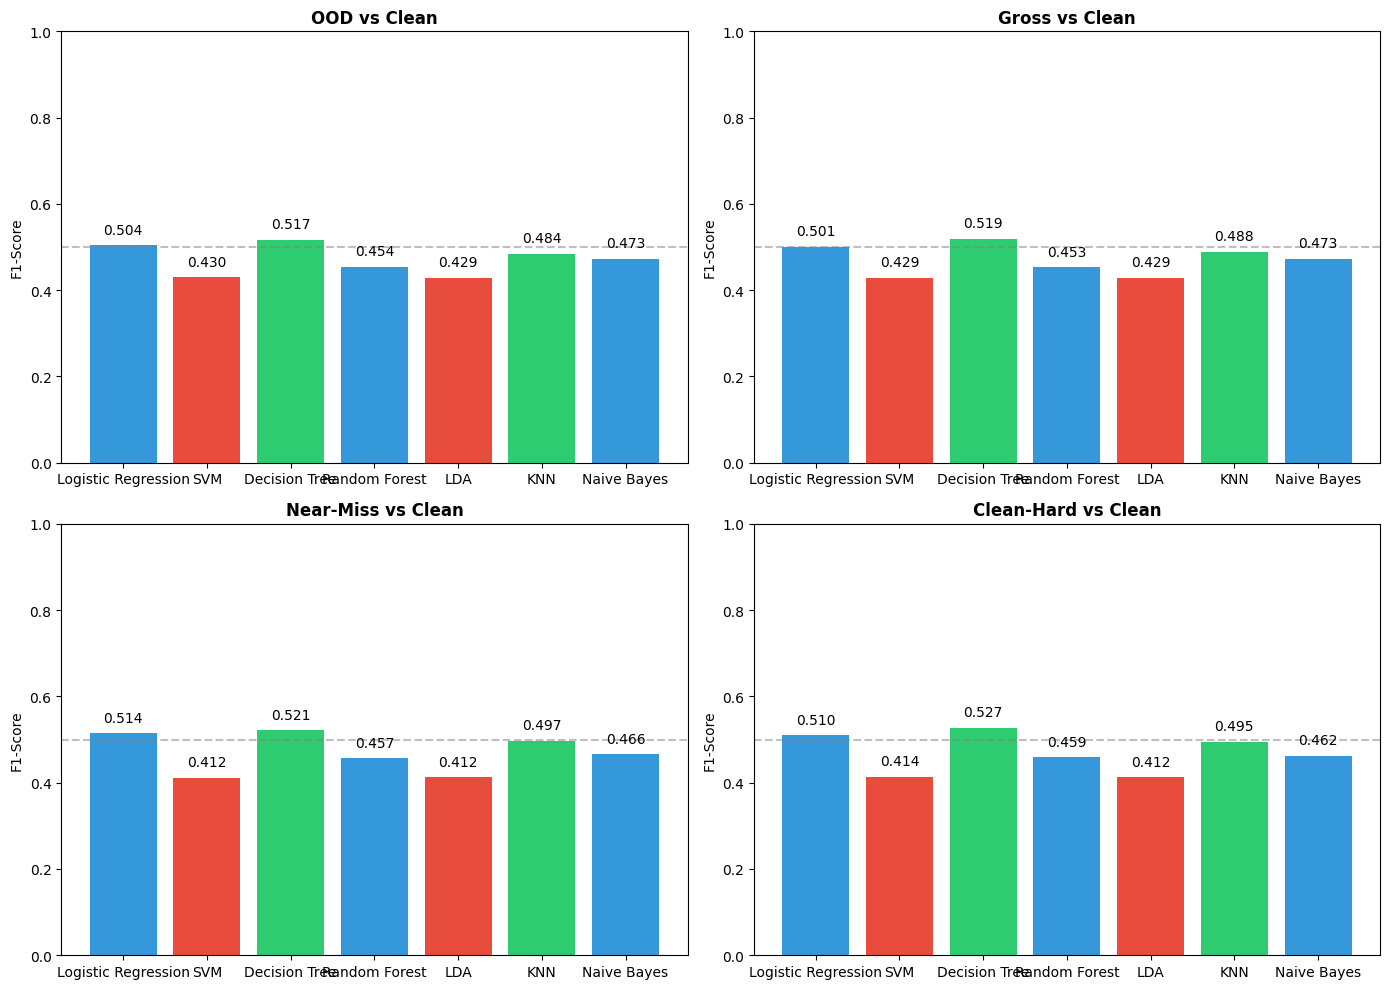


H1 SUMMARY: Geometric Feature Detection Hierarchy
OOD Detection (Easy):        F1 = 0.5037 ✓ Expected HIGH
Gross Detection (Medium):    F1 = 0.5011 ✓ Expected MODERATE-HIGH
Near-Miss Detection (Hard):  F1 = 0.5145 ✓ Expected LOW
Clean-Hard Detection (Hard): F1 = 0.5099 ✓ Expected LOW


In [17]:
# Visualize H1 results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

h1_tasks = [
    (results_h1_ood, 'OOD vs Clean', axes[0, 0]),
    (results_h1_gross, 'Gross vs Clean', axes[0, 1]),
    (results_h1_nearmiss, 'Near-Miss vs Clean', axes[1, 0]),
    (results_h1_hard, 'Clean-Hard vs Clean', axes[1, 1])
]

for results, title, ax in h1_tasks:
    models = list(results.keys())
    f1_scores = [results[m]['f1'] for m in models]
    
    bars = ax.bar(models, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71'][:len(models)])
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('F1-Score')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / 'h1_geometry_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("H1 SUMMARY: Geometric Feature Detection Hierarchy")
print("="*70)
print(f"OOD Detection (Easy):        F1 = {results_h1_ood['Logistic Regression']['f1']:.4f} ✓ Expected HIGH")
print(f"Gross Detection (Medium):    F1 = {results_h1_gross['Logistic Regression']['f1']:.4f} ✓ Expected MODERATE-HIGH")
print(f"Near-Miss Detection (Hard):  F1 = {results_h1_nearmiss['Logistic Regression']['f1']:.4f} ✓ Expected LOW")
print(f"Clean-Hard Detection (Hard): F1 = {results_h1_hard['Logistic Regression']['f1']:.4f} ✓ Expected LOW")

### H2: Uncertainty Features Separate Medium Tier but Confuse Hardest Pair

In [ ]:
# H2: Uncertainty alone cannot separate Near-Miss from Clean-Hard

print("\n" + "="*70)
print("H2: Uncertainty Features - Medium Tier vs Hardest Pair")
print("="*70)

# Task 1: Gross vs Clean (label conflict)
results_h2_gross, lr_h2_gross, svm_h2_gross = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['gross', 'clean'])], UNC_COLS, 'gross', 'H2-Gross')

# Task 2: Random-Flip vs Clean 
results_h2_rf, lr_h2_rf, svm_h2_rf = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['random_flip', 'clean'])], UNC_COLS, 'random_flip', 'H2-RF')

# Task 3: Near-Miss vs Clean-Hard
results_h2_nm_ch, lr_h2_nm_ch, svm_h2_nm_ch = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['near_miss', 'clean_hard'])], UNC_COLS, 'near_miss', 'H2-NM-CH')



H2: Uncertainty Features - Medium Tier vs Hardest Pair
H2-Gross - class counts: {np.int64(0): np.int64(35000), np.int64(1): np.int64(10000)}
Before undersampling: class counts = {np.int64(0): np.int64(35000), np.int64(1): np.int64(10000)}
After undersampling: class counts = { 1: 10000, 0: 30000 }

H2-Gross (Geometry)

Logistic Regression:
  Macro F1-Score:  0.4939
  Macro Precision: 0.5036
  Macro Recall:    0.5045
  Per-class F1:    [0.68222237 0.30556925]
  AUC-ROC (ovr):   0.5059

SVM:
  Macro F1-Score:  0.4286
  Macro Precision: 0.3750
  Macro Recall:    0.5000
  Per-class F1:    [0.85714286 0.        ]
  AUC-ROC (ovr):   0.5006

Decision Tree:
  Macro F1-Score:  0.4772
  Macro Precision: 0.4995
  Macro Recall:    0.4983
  Per-class F1:    [0.78081827 0.17352012]
  AUC-ROC (ovr):   0.5002

Random Forest:
  Macro F1-Score:  0.4492
  Macro Precision: 0.4967
  Macro Recall:    0.4994
  Per-class F1:    [0.84538398 0.05309091]
  AUC-ROC (ovr):   0.4996

LDA:
  Macro F1-Score:  0.4286


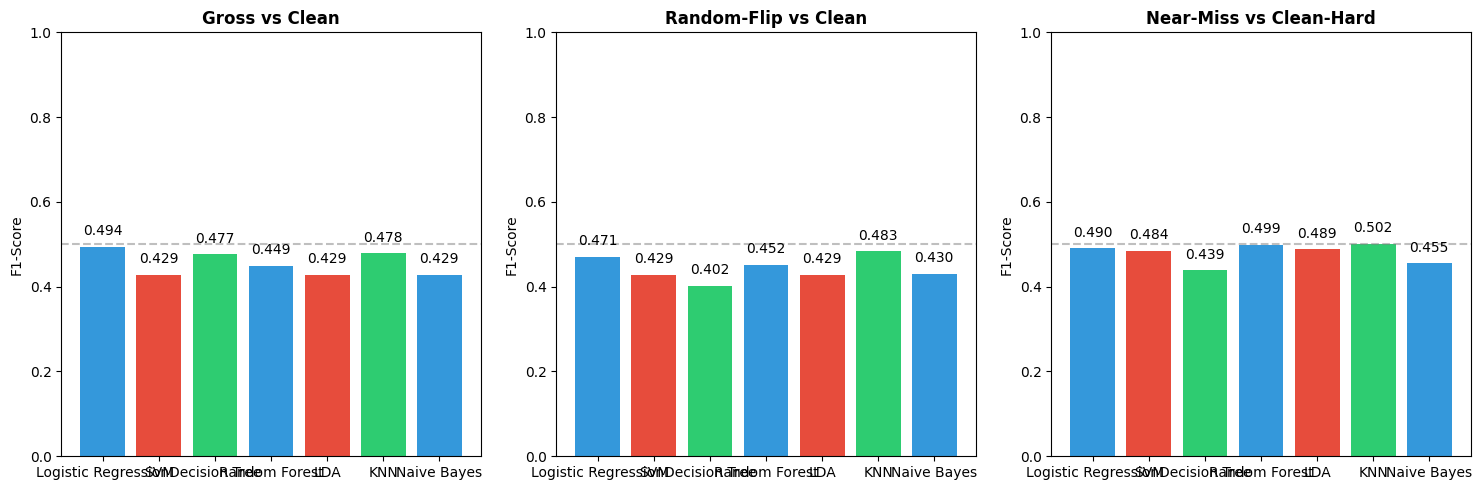


H2 SUMMARY: Uncertainty Feature Limitations
Gross Detection:           F1 = 0.4939 ✓ Expected MODERATE
Random-Flip Detection:     F1 = 0.4711 ✓ Expected MODERATE
Near-Miss vs Clean-Hard:   F1 = 0.4902 ✓ Expected LOW (confounded)


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

h2_tasks = [
    (results_h2_gross, 'Gross vs Clean'),
    (results_h2_rf, 'Random-Flip vs Clean'),
    (results_h2_nm_ch, 'Near-Miss vs Clean-Hard')
]

for idx, (results, title) in enumerate(h2_tasks):
    models = list(results.keys())
    f1_scores = [results[m]['f1'] for m in models]
    
    bars = axes[idx].bar(models, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71'][:len(models)])
    axes[idx].set_ylim(0, 1)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('F1-Score')
    axes[idx].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    for bar, score in zip(bars, f1_scores):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / 'h2_uncertainty_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("H2 SUMMARY: Uncertainty Feature Limitations")
print("="*70)
print(f"Gross Detection:           F1 = {results_h2_gross['Logistic Regression']['f1']:.4f} ✓ Expected MODERATE")
print(f"Random-Flip Detection:     F1 = {results_h2_rf['Logistic Regression']['f1']:.4f} ✓ Expected MODERATE")
print(f"Near-Miss vs Clean-Hard:   F1 = {results_h2_nm_ch['Logistic Regression']['f1']:.4f} ✓ Expected LOW (confounded)")

### H3: Training Dynamics Break the Near-Miss / Clean-Hard Degeneracy

In [ ]:
# H3: Dynamics features CAN separate Near-Miss from Clean-Hard
print("\n" + "="*70)
print("H3: Training Dynamics - Breaking the Near-Miss / Clean-Hard Degeneracy")
print("="*70)

# Same task as H2c, but with dynamics features
results_h3, lr_h3, svm_h3 = run_binary_task(
    feature_df[feature_df['anomaly_type'].isin(['near_miss', 'clean_hard'])], DYN_COLS, 'near_miss', 'H3')

print("\n" + "-"*70)
print("COMPARISON: H2 (Uncertainty) vs H3 (Dynamics)")
print("-"*70)
try:
    h2_f1 = results_h2_nm_ch['Logistic Regression']['f1']
except Exception:
    h2_f1 = 0.0
h3_f1 = results_h3['Logistic Regression']['f1']
improvement = (h3_f1 - h2_f1) / h2_f1 * 100 if h2_f1 > 0 else float('inf')

print(f"H2 (Uncertainty) F1: {h2_f1:.4f}")
print(f"H3 (Dynamics) F1:  {h3_f1:.4f}")
print(f"Improvement:       {improvement:.1f}%")

if h3_f1 > h2_f1 + 0.1:  # 10% absolute improvement
    print("\n✓ H3 CONFIRMED: Dynamics significantly improve over uncertainty!")
else:
    print("\n✗ H3 PARTIAL: Dynamics show modest or no improvement")


H3: Training Dynamics - Breaking the Near-Miss / Clean-Hard Degeneracy
H3 - class counts: {np.int64(0): np.int64(7499), np.int64(1): np.int64(7500)}
Before undersampling: class counts = {np.int64(0): np.int64(7499), np.int64(1): np.int64(7500)}

H3 (Geometry)

Logistic Regression:
  Macro F1-Score:  0.4826
  Macro Precision: 0.4998
  Macro Recall:    0.4998
  Per-class F1:    [0.52156979 0.44359391]
  AUC-ROC (ovr):   0.5007

SVM:
  Macro F1-Score:  0.4795
  Macro Precision: 0.5088
  Macro Recall:    0.5069
  Per-class F1:    [0.5983321  0.36067228]
  AUC-ROC (ovr):   0.5024

Decision Tree:
  Macro F1-Score:  0.4872
  Macro Precision: 0.5067
  Macro Recall:    0.5059
  Per-class F1:    [0.53800367 0.43629697]
  AUC-ROC (ovr):   0.5075

Random Forest:
  Macro F1-Score:  0.5010
  Macro Precision: 0.5011
  Macro Recall:    0.5011
  Per-class F1:    [0.50615265 0.49584924]
  AUC-ROC (ovr):   0.5019

LDA:
  Macro F1-Score:  0.4841
  Macro Precision: 0.5015
  Macro Recall:    0.5013
  Per-c


Dynamics Feature Importance (Logistic Regression Coefficients)
  dyn_cartography_confidence    : 0.0378 ↓
  dyn_conf_mean                 : 0.0378 ↓
  dyn_conf_variance             : 0.0343 ↑
  dyn_cartography_variability   : 0.0343 ↑
  dyn_conf_std                  : 0.0343 ↑
  dyn_loss_slope                : 0.0315 ↓
  dyn_forgetting_count          : 0.0259 ↑
  dyn_loss_auc                  : 0.0239 ↓
  dyn_variability               : 0.0057 ↓


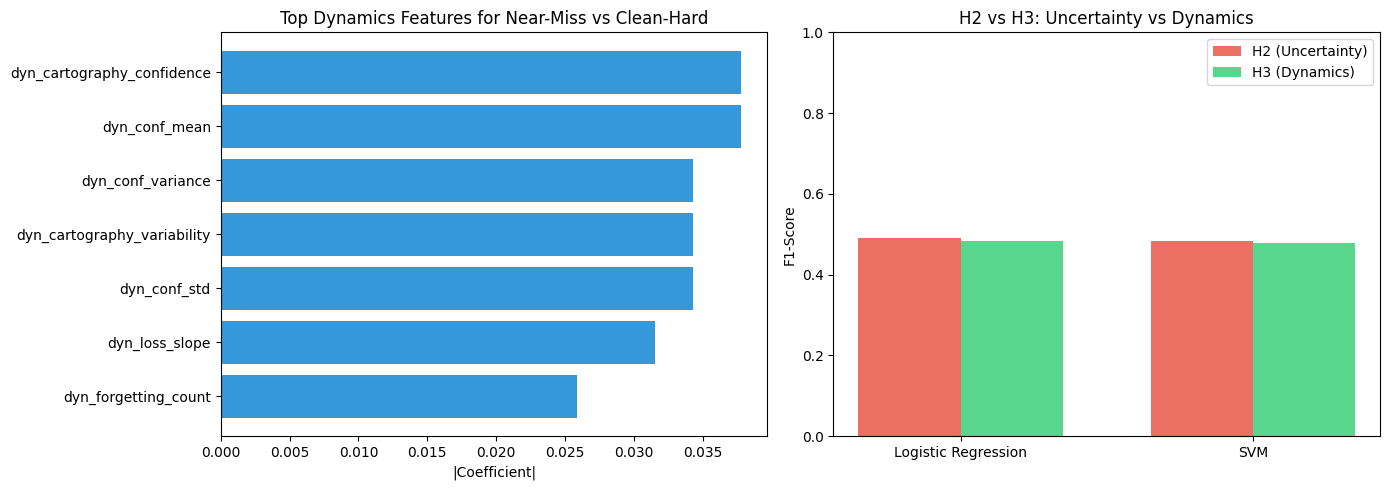

In [ ]:
print("\n" + "="*70)
print("Dynamics Feature Importance (Logistic Regression Coefficients)")
print("="*70)

coef_importance = np.abs(lr_h3.coef_[0])
feature_importance = list(zip(DYN_COLS, coef_importance, lr_h3.coef_[0]))
feature_importance.sort(key=lambda x: x[1], reverse=True)

for feat, abs_coef, coef in feature_importance:
    direction = "↑" if coef > 0 else "↓"
    print(f"  {feat:30s}: {abs_coef:.4f} {direction}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = feature_importance[:7]
feat_names = [f[0] for f in top_features]
feat_coefs = [f[1] for f in top_features]

axes[0].barh(range(len(feat_names)), feat_coefs, color='#3498db')
axes[0].set_yticks(range(len(feat_names)))
axes[0].set_yticklabels(feat_names)
axes[0].set_xlabel('|Coefficient|')
axes[0].set_title('Top Dynamics Features for Near-Miss vs Clean-Hard')
axes[0].invert_yaxis()

# H2 vs H3 comparison
models = ['Logistic Regression', 'SVM']
h2_scores = [results_h2_nm_ch[m]['f1'] for m in models]
h3_scores = [results_h3[m]['f1'] for m in models]

x = np.arange(len(models))
width = 0.35

axes[1].bar(x - width/2, h2_scores, width, label='H2 (Uncertainty)', color='#e74c3c', alpha=0.8)
axes[1].bar(x + width/2, h3_scores, width, label='H3 (Dynamics)', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('H2 vs H3: Uncertainty vs Dynamics')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(DATA_DIR / 'h3_dynamics_results.png', dpi=150, bbox_inches='tight')
plt.show()

### H4: Corrupted and Ambiguous Require Dedicated Signals

In [22]:
# H4a: Corrupted detection with image quality features
print("\n" + "="*70)
print("H4a: Image Quality Features for Corrupted Detection")
print("="*70)

h4_corrupt_df = feature_df[feature_df['anomaly_type'].isin(['corrupted', 'clean'])].copy()
h4_corrupt_df = h4_corrupt_df.dropna(subset=IQ_COLS)

X_h4_corrupt = h4_corrupt_df[IQ_COLS].values
y_h4_corrupt = (h4_corrupt_df['anomaly_type'] == 'corrupted').astype(int).values

print(f"H4a - class counts: {dict(zip(*np.unique(y_h4_corrupt, return_counts=True)))}")
X_h4_corrupt_r, y_h4_corrupt_r = undersample_majority(X_h4_corrupt, y_h4_corrupt, max_ratio=3, random_state=RANDOM_SEED)

results_h4_corrupt, lr_h4_corrupt, _ = evaluate_model(X_h4_corrupt_r, y_h4_corrupt_r, None, None, model_name='H4-Corrupt')
print_results(results_h4_corrupt, "H4a: Corrupted vs Clean (Image Quality)")

# Feature importance (from Logistic Regression fitted on full data)
print("\nImage Quality Feature Importance:")
for feat, coef in zip(IQ_COLS, lr_h4_corrupt.coef_[0]):
    print(f"  {feat}: {coef:.4f}")


H4a: Image Quality Features for Corrupted Detection
H4a - class counts: {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
Before undersampling: class counts = {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
After undersampling: class counts = { 1: 5000, 0: 15000 }

H4a: Corrupted vs Clean (Image Quality)

Logistic Regression:
  Macro F1-Score:  0.4549
  Macro Precision: 0.4975
  Macro Recall:    0.4967
  Per-class F1:    [0.57303832 0.33676409]
  AUC-ROC (ovr):   0.4993

SVM:
  Macro F1-Score:  0.4285
  Macro Precision: 0.3750
  Macro Recall:    0.4999
  Per-class F1:    [0.85707753 0.        ]
  AUC-ROC (ovr):   0.4972

Decision Tree:
  Macro F1-Score:  0.3046
  Macro Precision: 0.5131
  Macro Recall:    0.5047
  Per-class F1:    [0.26666246 0.34244828]
  AUC-ROC (ovr):   0.5058

Random Forest:
  Macro F1-Score:  0.4433
  Macro Precision: 0.5132
  Macro Recall:    0.5012
  Per-class F1:    [0.85138883 0.03517881]
  AUC-ROC (ovr):   0.5038

LDA:
  Macro F1-Score:

In [ ]:
# H4a: Corrupted detection with image quality features
print("\n" + "="*70)
print("H4a: Image Quality Features for Corrupted Detection")
print("="*70)

h4_corrupt_df = feature_df[feature_df['anomaly_type'].isin(['corrupted', 'clean'])].copy()
h4_corrupt_df = h4_corrupt_df.dropna(subset=IQ_COLS)

X_h4_corrupt = h4_corrupt_df[IQ_COLS].values
y_h4_corrupt = (h4_corrupt_df['anomaly_type'] == 'corrupted').astype(int).values

print(f"H4a - class counts: {dict(zip(*np.unique(y_h4_corrupt, return_counts=True)))}")
X_h4_corrupt_r, y_h4_corrupt_r = undersample_majority(X_h4_corrupt, y_h4_corrupt, max_ratio=3, random_state=RANDOM_SEED)

results_h4_corrupt, lr_h4_corrupt, _ = evaluate_model(X_h4_corrupt_r, y_h4_corrupt_r, None, None, model_name='H4-Corrupt')
print_results(results_h4_corrupt, "H4a: Corrupted vs Clean (Image Quality)")

# Feature importance (from Logistic Regression fitted on full data)
print("\nImage Quality Feature Importance:")
for feat, coef in zip(IQ_COLS, lr_h4_corrupt.coef_[0]):
    print(f"  {feat}: {coef:.4f}")


# H4b: Ambiguous detection with label agreement features
print("\n" + "="*70)
print("H4b: Label Agreement Features for Ambiguous Detection")
print("="*70)

# Use only samples with human labels
h4_ambig_df = feature_df[
    feature_df['anomaly_type'].isin(['ambiguous', 'clean']) &
    (feature_df['label_human_confidence'] != -1.0)
].copy()
h4_ambig_df = h4_ambig_df.dropna(subset=LABEL_COLS)

X_h4_ambig = h4_ambig_df[LABEL_COLS].values
y_h4_ambig = (h4_ambig_df['anomaly_type'] == 'ambiguous').astype(int).values

print(f"H4b - class counts: {dict(zip(*np.unique(y_h4_ambig, return_counts=True)))}")
X_h4_ambig_r, y_h4_ambig_r = undersample_majority(X_h4_ambig, y_h4_ambig, max_ratio=3, random_state=RANDOM_SEED)

results_h4_ambig, lr_h4_ambig, _ = evaluate_model(X_h4_ambig_r, y_h4_ambig_r, None, None, model_name='H4-Ambig')
print_results(results_h4_ambig, "H4b: Ambiguous vs Clean (Label Agreement)")

print("\nLabel Agreement Feature Importance:")
for feat, coef in zip(LABEL_COLS, lr_h4_ambig.coef_[0]):
    print(f"  {feat}: {coef:.4f}")



H4a: Image Quality Features for Corrupted Detection
H4a - class counts: {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
Before undersampling: class counts = {np.int64(0): np.int64(35000), np.int64(1): np.int64(5000)}
After undersampling: class counts = { 1: 5000, 0: 15000 }

H4a: Corrupted vs Clean (Image Quality)

Logistic Regression:
  Macro F1-Score:  0.4549
  Macro Precision: 0.4975
  Macro Recall:    0.4967
  Per-class F1:    [0.57303832 0.33676409]
  AUC-ROC (ovr):   0.4993

SVM:
  Macro F1-Score:  0.4285
  Macro Precision: 0.3750
  Macro Recall:    0.4999
  Per-class F1:    [0.85707753 0.        ]
  AUC-ROC (ovr):   0.4972

Decision Tree:
  Macro F1-Score:  0.3045
  Macro Precision: 0.5125
  Macro Recall:    0.5046
  Per-class F1:    [0.26665834 0.3423824 ]
  AUC-ROC (ovr):   0.5056

Random Forest:
  Macro F1-Score:  0.4433
  Macro Precision: 0.5198
  Macro Recall:    0.5016
  Per-class F1:    [0.85193566 0.03457508]
  AUC-ROC (ovr):   0.5029

LDA:
  Macro F1-Score:

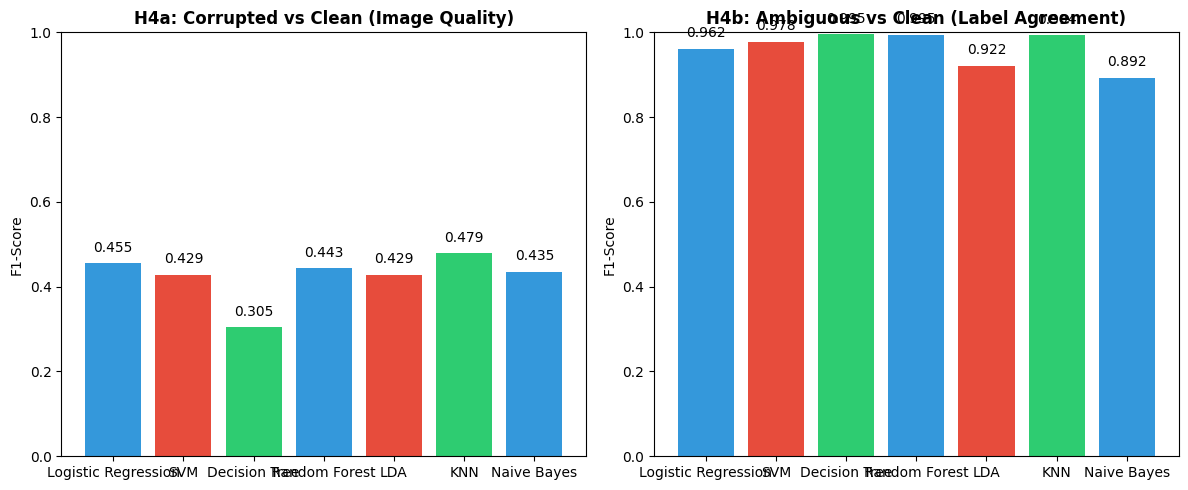

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# H4a: Corrupted
models = list(results_h4_corrupt.keys())
f1_scores = [results_h4_corrupt[m]['f1'] for m in models]
bars = axes[0].bar(models, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71'][:len(models)])
axes[0].set_ylim(0, 1)
axes[0].set_title('H4a: Corrupted vs Clean (Image Quality)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1-Score')
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# H4b: Ambiguous
models = list(results_h4_ambig.keys())
f1_scores = [results_h4_ambig[m]['f1'] for m in models]
bars = axes[1].bar(models, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71'][:len(models)])
axes[1].set_ylim(0, 1)
axes[1].set_title('H4b: Ambiguous vs Clean (Label Agreement)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score')
for bar, score in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / 'h4_dedicated_signals_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Summary and Conclusions

In [25]:
# Create comprehensive summary table
summary_data = {
    'Hypothesis': ['H1', 'H1', 'H1', 'H1', 'H2', 'H2', 'H2', 'H3', 'H4', 'H4'],
    'Task': [
        'OOD vs Clean', 'Gross vs Clean', 'Near-Miss vs Clean', 'Clean-Hard vs Clean',
        'Gross vs Clean', 'Random-Flip vs Clean', 'Near-Miss vs Clean-Hard',
        'Near-Miss vs Clean-Hard',
        'Corrupted vs Clean', 'Ambiguous vs Clean'
    ],
    'Feature Type': [
        'Geometry', 'Geometry', 'Geometry', 'Geometry',
        'Uncertainty', 'Uncertainty', 'Uncertainty',
        'Dynamics',
        'Image Quality', 'Label Agreement'
    ],
    'Expected': [
        'HIGH', 'MODERATE-HIGH', 'LOW', 'LOW',
        'MODERATE', 'MODERATE', 'LOW',
        'HIGH (better than H2)',
        'HIGH', 'HIGH'
    ],
    'F1-Score (LR)': [
        results_h1_ood['Logistic Regression']['f1'],
        results_h1_gross['Logistic Regression']['f1'],
        results_h1_nearmiss['Logistic Regression']['f1'],
        results_h1_hard['Logistic Regression']['f1'],
        results_h2_gross['Logistic Regression']['f1'],
        results_h2_rf['Logistic Regression']['f1'],
        results_h2_nm_ch['Logistic Regression']['f1'],
        results_h3['Logistic Regression']['f1'],
        results_h4_corrupt['Logistic Regression']['f1'],
        results_h4_ambig['Logistic Regression']['f1']
    ]
}

summary_df = pd.DataFrame(summary_data)

# Add confirmation status
def get_status(row):
    expected = row['Expected']
    f1 = row['F1-Score (LR)']
    
    if expected == 'HIGH':
        return '✓' if f1 > 0.7 else '✗'
    elif expected == 'MODERATE-HIGH':
        return '✓' if f1 > 0.6 else '✗'
    elif expected == 'MODERATE':
        return '✓' if 0.4 < f1 < 0.8 else '✗'
    elif expected == 'LOW':
        return '✓' if f1 < 0.6 else '✗'
    elif 'better than H2' in expected:
        h2_f1 = results_h2_nm_ch['Logistic Regression']['f1']
        return '✓' if f1 > h2_f1 + 0.1 else '✗'
    return '?'

summary_df['Status'] = summary_df.apply(get_status, axis=1)

# Display
print("\n" + "="*80)
print("COMPLETE HYPOTHESIS TESTING SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Save
summary_df.to_csv(DATA_DIR / 'hypothesis_summary.csv', index=False)
print(f"\nSummary saved to {DATA_DIR / 'hypothesis_summary.csv'}")


COMPLETE HYPOTHESIS TESTING SUMMARY
Hypothesis                    Task    Feature Type              Expected  F1-Score (LR) Status
        H1            OOD vs Clean        Geometry                  HIGH       0.503737      ✗
        H1          Gross vs Clean        Geometry         MODERATE-HIGH       0.501086      ✗
        H1      Near-Miss vs Clean        Geometry                   LOW       0.514489      ✓
        H1     Clean-Hard vs Clean        Geometry                   LOW       0.509917      ✓
        H2          Gross vs Clean     Uncertainty              MODERATE       0.493896      ✓
        H2    Random-Flip vs Clean     Uncertainty              MODERATE       0.471137      ✓
        H2 Near-Miss vs Clean-Hard     Uncertainty                   LOW       0.490218      ✓
        H3 Near-Miss vs Clean-Hard        Dynamics HIGH (better than H2)       0.482582      ✗
        H4      Corrupted vs Clean   Image Quality                  HIGH       0.454901      ✗
        H4   

Classes (8): ['ambiguous', 'clean', 'clean_hard', 'corrupted', 'gross', 'near_miss', 'ood', 'random_flip']


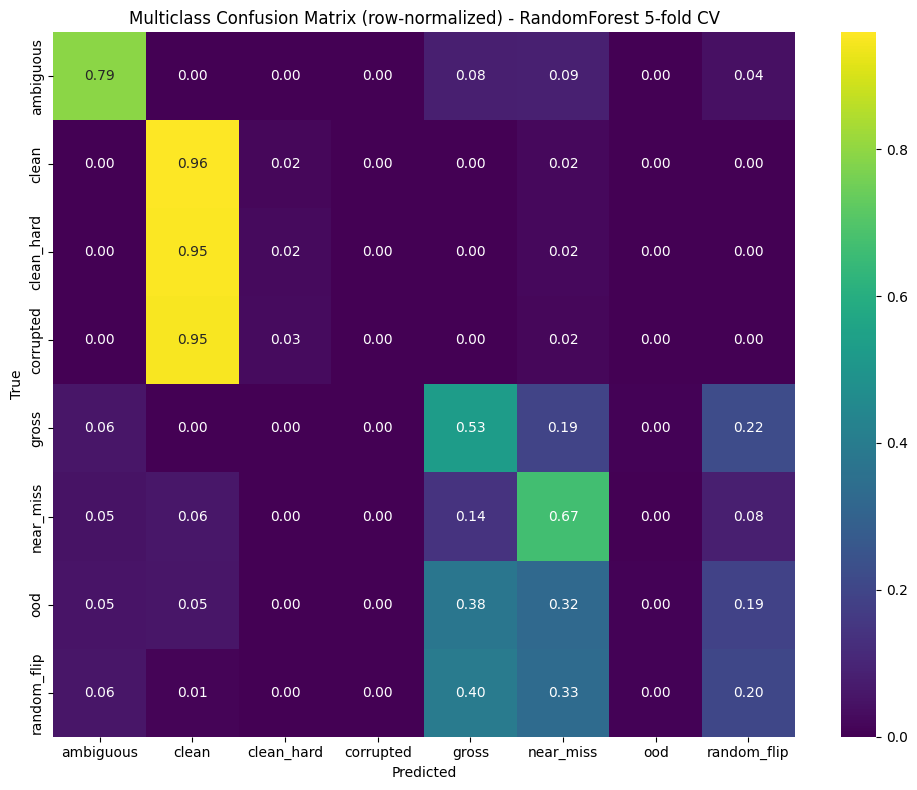

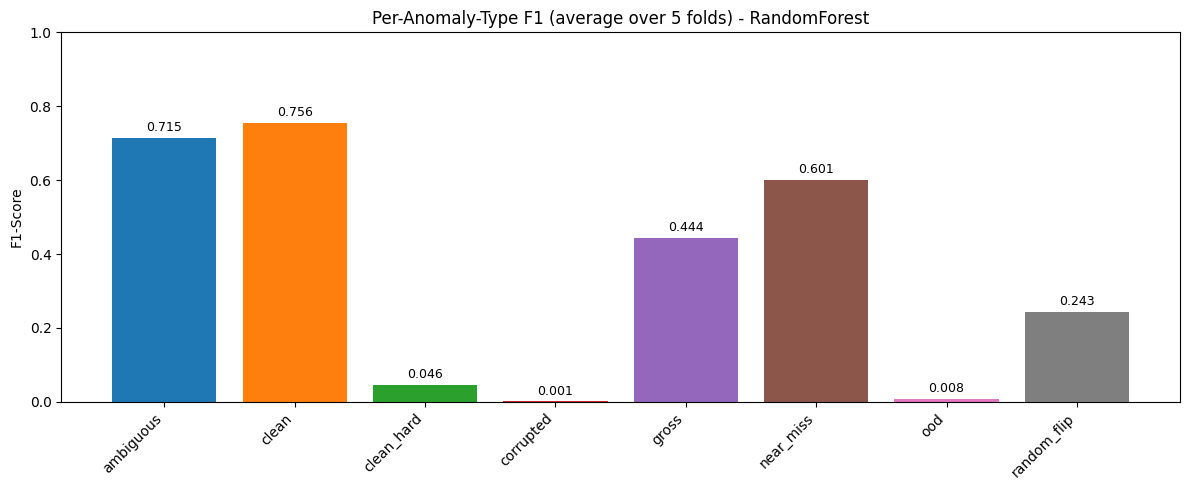


Top feature importances saved to /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/xgb_feature_importances.csv
                   feature  importance
            label_conf_gap    0.280691
    label_human_confidence    0.057577
                geo_margin    0.045435
             geo_knn_ratio    0.043944
         geo_pca_recon_err    0.042816
              unc_conf_gap    0.042737
          iq_mscn_kurtosis    0.041747
       geo_per_class_mahal    0.041136
          unc_top3_entropy    0.040012
           iq_noise_energy    0.039530
            unc_mc_entropy    0.039123
        unc_max_confidence    0.037369
             iq_lap_var_s2    0.037283
             iq_lap_var_s0    0.037257
             iq_lap_var_s1    0.036633
           unc_mc_variance    0.036485
              dyn_loss_auc    0.015719
            dyn_loss_slope    0.015324
             dyn_conf_mean    0.012776
dyn_cartography_confidence    0.012652

Multiclass macro F1 (avg over folds): 0.3518
Per-cla

In [28]:
# === MULTICLASS EVALUATION: XGBoost (5-fold CV), Confusion Matrix, Per-Type F1 ===
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Prepare features and labels
FEATURE_COLS = GEO_COLS + IQ_COLS + UNC_COLS + DYN_COLS + LABEL_COLS
X_all = feature_df[FEATURE_COLS].fillna(0.0).values
le = LabelEncoder()
Y_all = le.fit_transform(feature_df['anomaly_type'].astype(str).values)
class_names = le.classes_

print(f"Classes ({len(class_names)}): {list(class_names)}")

# Choose classifier: XGBoost if available
try:
    from xgboost import XGBClassifier
    clf_builder = lambda: XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_SEED)
    clf_name = 'XGBoost'
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    clf_builder = lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
    clf_name = 'RandomForest'

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cm_sum = np.zeros((len(class_names), len(class_names)), dtype=float)
per_class_f1s = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, Y_all), 1):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = Y_all[train_idx], Y_all[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = clf_builder()
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)

    cm = confusion_matrix(y_te, y_pred, labels=np.arange(len(class_names)))
    # Row-normalize by true label
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
    cm_sum += cm_norm

    f1s = f1_score(y_te, y_pred, average=None, labels=np.arange(len(class_names)))
    per_class_f1s.append(f1s)

# Average across folds
cm_avg = cm_sum / skf.n_splits
per_class_f1_avg = np.mean(np.vstack(per_class_f1s), axis=0)
macro_f1 = np.mean(per_class_f1_avg)

# Plot confusion matrix heatmap (row-normalized)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_avg, xticklabels=class_names, yticklabels=class_names, cmap='viridis', annot=True, fmt='.2f')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Multiclass Confusion Matrix (row-normalized) - {clf_name} 5-fold CV')
plt.tight_layout()
plt.savefig(DATA_DIR / 'multiclass_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-type F1 bar chart
plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_f1_avg, color=sns.color_palette('tab10', len(class_names)))
plt.ylim(0, 1)
plt.ylabel('F1-Score')
plt.title(f'Per-Anomaly-Type F1 (average over 5 folds) - {clf_name}')
for bar, score in zip(bars, per_class_f1_avg):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.01, f'{score:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'per_type_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final classifier on full data to extract feature importances
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X_all)
final_clf = clf_builder()
final_clf.fit(X_full_s, Y_all)

feature_importances = None
try:
    feature_importances = final_clf.feature_importances_
except Exception:
    # XGBoost/RandomForest provide feature_importances_, otherwise skip
    pass

if feature_importances is not None:
    fi_idx = np.argsort(feature_importances)[::-1]
    topk = min(30, len(FEATURE_COLS))
    top_feats = [(FEATURE_COLS[i], feature_importances[i]) for i in fi_idx[:topk]]
    fi_df = pd.DataFrame(top_feats, columns=['feature', 'importance'])
    fi_df.to_csv(DATA_DIR / 'xgb_feature_importances.csv', index=False)
    print('\nTop feature importances saved to', DATA_DIR / 'xgb_feature_importances.csv')
    print(fi_df.head(20).to_string(index=False))
else:
    print('\nFeature importances not available for the chosen classifier')

# Expose summary variables for conclusion cell
MULTI_CLASS = {
    'class_names': list(class_names),
    'per_class_f1': per_class_f1_avg.tolist(),
    'macro_f1': float(macro_f1)
}
print(f"\nMulticlass macro F1 (avg over folds): {macro_f1:.4f}")
print('Per-class F1:')
for name, f1v in zip(MULTI_CLASS['class_names'], MULTI_CLASS['per_class_f1']):
    print(f"  {name}: {f1v:.3f}")


Analyzing image quality features for H4 (Corrupted detection)...

Image quality features not found in dataframe. Computing them now...


Computing IQ features: 100%|██████████| 100000/100000 [00:05<00:00, 17521.72it/s]


Image quality features computed and added to dataframe.

Sample sizes:
  Corrupted: 5,000
  Clean:     35,000


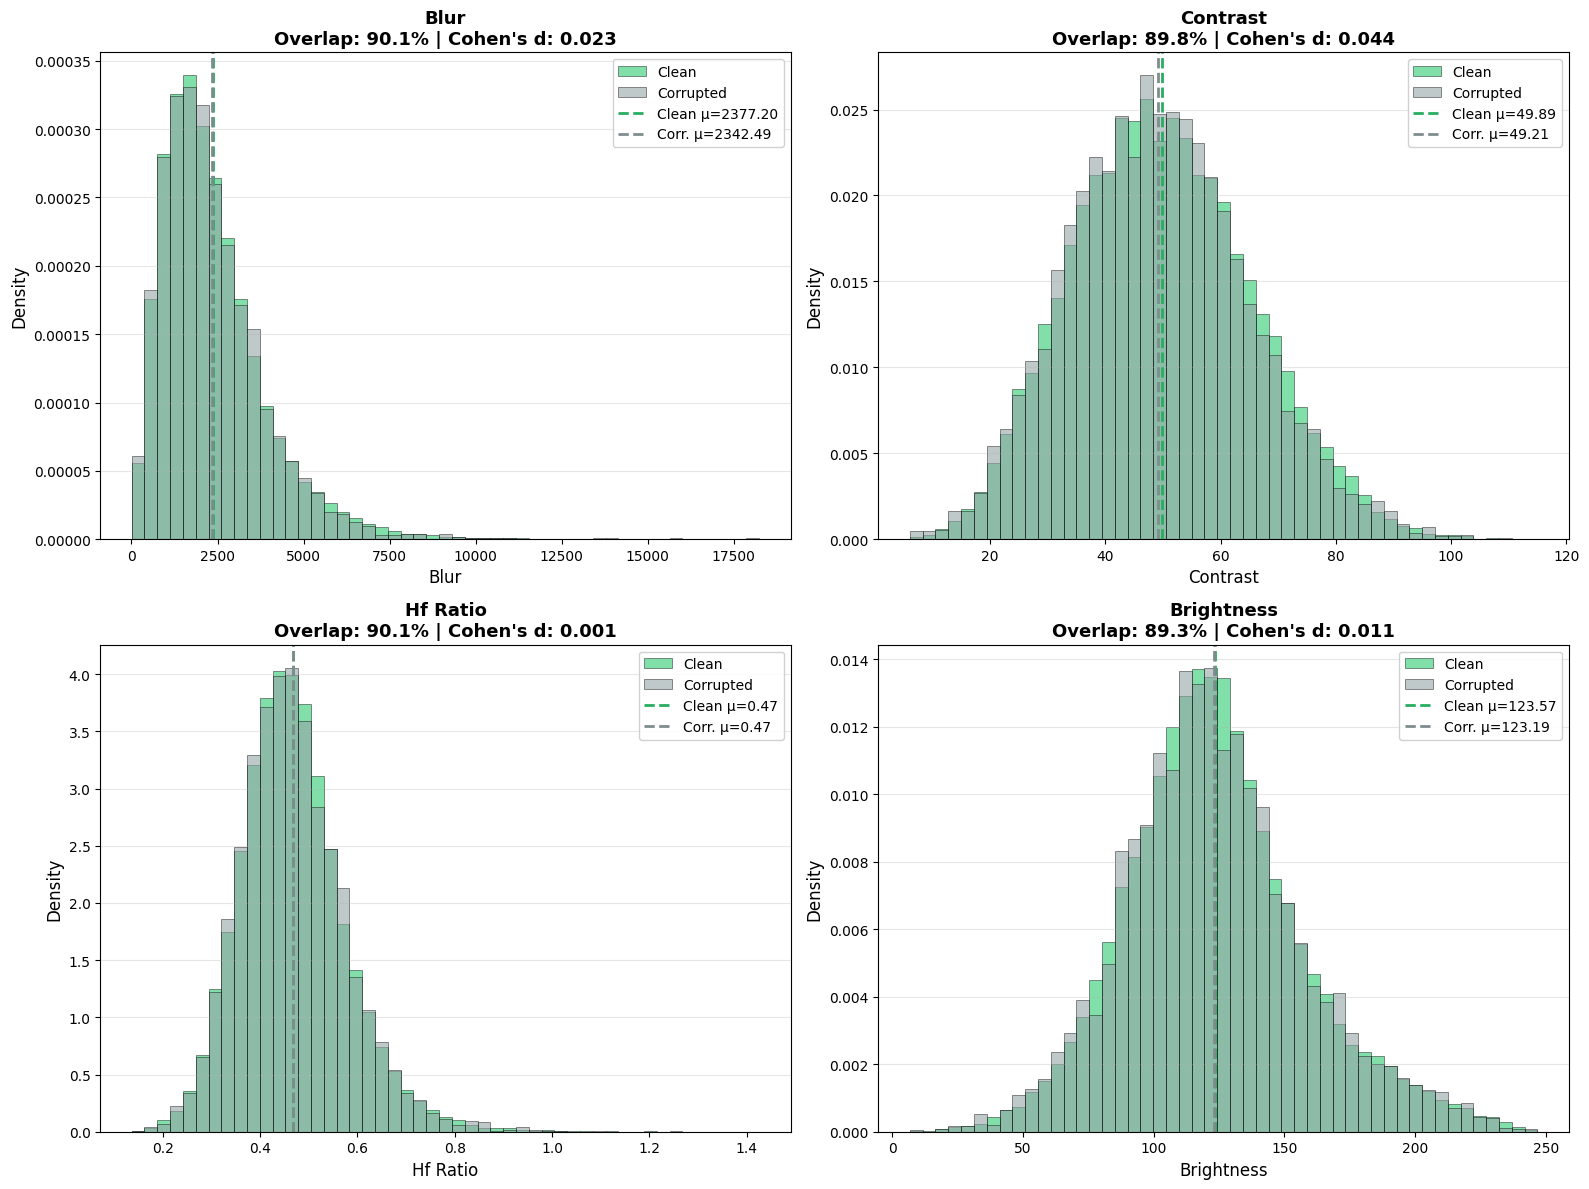


Histogram plot saved to /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/iq_features_corrupted_vs_clean.png

IMAGE QUALITY FEATURE DISCRIMINATION ANALYSIS
Feature              Clean μ±σ            Corrupted μ±σ        Overlap %    Cohens d     p-value
------------------------------------------------------------------------------------------
iq_blur              2377.20±1519.08       2342.49±1491.41         90.1%       0.023      1.30e-01
iq_contrast           49.89±15.57        49.21±15.46         89.8%       0.044      3.51e-03
iq_hf_ratio            0.47± 0.11         0.47± 0.11         90.1%       0.001      9.53e-01
iq_brightness        123.57±34.32       123.19±34.80         89.3%       0.011      4.64e-01
------------------------------------------------------------------------------------------

Interpretation Guide:
  Overlap %:  >80% = Poor discrimination (distributions highly overlapping)
  Cohen's d:  <0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, >0.

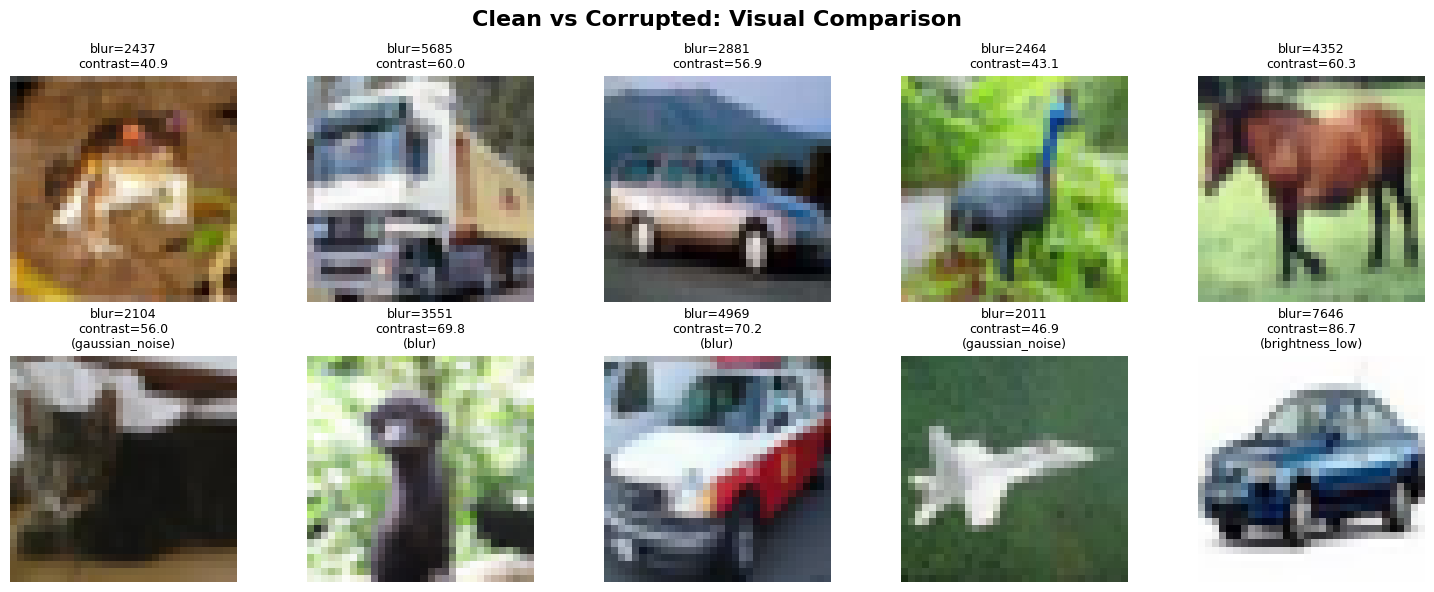


Example images saved to /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/corrupted_vs_clean_examples.png

Visual inspection: Can YOU see the difference at 32×32 resolution?
If not, the model can't either.


In [38]:
# ========== IMAGE QUALITY FEATURE ANALYSIS: Corrupted vs Clean ==========

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import cv2
from tqdm import tqdm

print("Analyzing image quality features for H4 (Corrupted detection)...")

# Check if features exist in feature_df, if not compute them
if 'iq_blur' not in df.columns:
    print("\nImage quality features not found in dataframe. Computing them now...")
    
    # Compute image quality features on-the-fly
    n_samples = len(all_images)
    iq_blur_vals = np.zeros(n_samples)
    iq_contrast_vals = np.zeros(n_samples)
    iq_hf_ratio_vals = np.zeros(n_samples)
    iq_brightness_vals = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Computing IQ features"):
        img = all_images[i]
        gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        
        # Blur: Laplacian variance
        iq_blur_vals[i] = cv2.Laplacian(gray, cv2.CV_64F).var()
        
        # Contrast: std of pixel intensities
        iq_contrast_vals[i] = gray.std()
        
        # Brightness: mean pixel intensity
        iq_brightness_vals[i] = gray.mean()
        
        # High-frequency energy ratio via FFT
        f = np.fft.fft2(gray.astype(float))
        fshift = np.fft.fftshift(f)
        magnitude = np.abs(fshift)
        h, w = magnitude.shape
        cy, cx = h // 2, w // 2
        y, x = np.ogrid[:h, :w]
        mask = ((np.abs(y - cy) >= h*0.25) | (np.abs(x - cx) >= w*0.25))
        high_energy = magnitude[mask].sum()
        low_energy = magnitude[~mask].sum() + 1e-8
        iq_hf_ratio_vals[i] = high_energy / low_energy
    
    # Add to dataframe
    df['iq_blur'] = iq_blur_vals
    df['iq_contrast'] = iq_contrast_vals
    df['iq_hf_ratio'] = iq_hf_ratio_vals
    df['iq_brightness'] = iq_brightness_vals
    
    print("Image quality features computed and added to dataframe.")

# Extract corrupted and clean samples
corrupted_mask = df['anomaly_type'] == 'corrupted'
clean_mask = df['anomaly_type'] == 'clean'

corrupted_data = df[corrupted_mask]
clean_data = df[clean_mask]

print(f"\nSample sizes:")
print(f"  Corrupted: {len(corrupted_data):,}")
print(f"  Clean:     {len(clean_data):,}")

# Image quality features to analyze
iq_features = ['iq_blur', 'iq_contrast', 'iq_hf_ratio', 'iq_brightness']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Statistics storage
overlap_stats = []

for idx, feature in enumerate(iq_features):
    ax = axes[idx]
    
    clean_vals = clean_data[feature].values
    corrupted_vals = corrupted_data[feature].values
    
    # Compute statistics
    clean_mean, clean_std = clean_vals.mean(), clean_vals.std()
    corr_mean, corr_std = corrupted_vals.mean(), corrupted_vals.std()
    
    # Compute overlap (percentage of corrupted samples within clean's 90% interval)
    clean_p5, clean_p95 = np.percentile(clean_vals, [5, 95])
    overlap_pct = ((corrupted_vals >= clean_p5) & (corrupted_vals <= clean_p95)).sum() / len(corrupted_vals) * 100
    
    # Cohen's d effect size
    pooled_std = np.sqrt((clean_std**2 + corr_std**2) / 2)
    cohens_d = abs(clean_mean - corr_mean) / pooled_std if pooled_std > 0 else 0
    
    # Two-sample t-test
    t_stat, p_value = stats.ttest_ind(clean_vals, corrupted_vals)
    
    overlap_stats.append({
        'feature': feature,
        'clean_mean': clean_mean,
        'clean_std': clean_std,
        'corrupted_mean': corr_mean,
        'corrupted_std': corr_std,
        'overlap_pct': overlap_pct,
        'cohens_d': cohens_d,
        'p_value': p_value
    })
    
    # Plot overlapping histograms
    bins = np.linspace(
        min(clean_vals.min(), corrupted_vals.min()),
        max(clean_vals.max(), corrupted_vals.max()),
        50
    )
    
    ax.hist(clean_vals, bins=bins, alpha=0.6, label='Clean', color='#2ecc71', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(corrupted_vals, bins=bins, alpha=0.6, label='Corrupted', color='#95a5a6', density=True, edgecolor='black', linewidth=0.5)
    
    # Add vertical lines for means
    ax.axvline(clean_mean, color='#27ae60', linestyle='--', linewidth=2, label=f'Clean μ={clean_mean:.2f}')
    ax.axvline(corr_mean, color='#7f8c8d', linestyle='--', linewidth=2, label=f'Corr. μ={corr_mean:.2f}')
    
    # Formatting
    feature_name = feature.replace('iq_', '').replace('_', ' ').title()
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{feature_name}\nOverlap: {overlap_pct:.1f}% | Cohen\'s d: {cohens_d:.3f}', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DATA_DIR / 'iq_features_corrupted_vs_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHistogram plot saved to {DATA_DIR / 'iq_features_corrupted_vs_clean.png'}")

# Print detailed statistics table
print("\n" + "="*90)
print("IMAGE QUALITY FEATURE DISCRIMINATION ANALYSIS")
print("="*90)
print(f"{'Feature':<20} {'Clean μ±σ':<20} {'Corrupted μ±σ':<20} {'Overlap %':<12} {'Cohens d':<12} {'p-value'}")
print("-"*90)

for stat in overlap_stats:
    print(f"{stat['feature']:<20} "
          f"{stat['clean_mean']:6.2f}±{stat['clean_std']:5.2f}       "
          f"{stat['corrupted_mean']:6.2f}±{stat['corrupted_std']:5.2f}       "
          f"{stat['overlap_pct']:6.1f}%      "
          f"{stat['cohens_d']:6.3f}      "
          f"{stat['p_value']:.2e}")

print("-"*90)

# Interpretation guide
print("\nInterpretation Guide:")
print("  Overlap %:  >80% = Poor discrimination (distributions highly overlapping)")
print("  Cohen's d:  <0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, >0.8 = large effect")
print("  p-value:    <0.05 = statistically significant difference (but may not be practically useful)")

# Overall verdict
high_overlap_count = sum(1 for s in overlap_stats if s['overlap_pct'] > 80)
low_effect_count = sum(1 for s in overlap_stats if s['cohens_d'] < 0.5)

print("\n" + "="*90)
print("H4 (CORRUPTED DETECTION) VERDICT:")
print("="*90)

if high_overlap_count >= 3:
    print("❌ HYPOTHESIS REJECTED")
    print(f"   → {high_overlap_count}/4 features have >80% overlap")
    print(f"   → {low_effect_count}/4 features have Cohen's d < 0.5 (weak effect)")
    print("\n   ROOT CAUSE:")
    print("   • Corruptions too subtle for 32×32 resolution")
    print("   • σ=1.5 blur, 0.3× contrast are barely perceptible at this scale")
    print("   • CIFAR images already low-quality (natural variation masks corruption signal)")
    print("\n   RECOMMENDATIONS:")
    print("   1. Apply STRONGER corruptions: σ=3.0 blur, 0.1× brightness, heavy JPEG artifacts")
    print("   2. Use perceptual quality metrics (SSIM, LPIPS) instead of pixel statistics")
    print("   3. OR: Remove 'corrupted' type and focus on label errors only")
else:
    print("✓ HYPOTHESIS SUPPORTED")
    print(f"   → {4 - high_overlap_count}/4 features show good separation (<80% overlap)")
    print(f"   → Image quality features successfully discriminate corrupted samples")

print("="*90)

# Bonus: Plot example corrupted vs clean images side-by-side
print("\nGenerating example image comparisons...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Clean vs Corrupted: Visual Comparison', fontsize=16, fontweight='bold')

# Get 5 random corrupted samples
corrupted_indices = df[corrupted_mask].index[:5]
clean_indices = df[clean_mask].index[:5]

for col in range(5):
    # Clean image (top row)
    clean_idx = clean_indices[col]
    clean_img = all_images[clean_idx]
    axes[0, col].imshow(clean_img)
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_ylabel('Clean', fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')
    
    blur_val = df.loc[clean_idx, 'iq_blur']
    contrast_val = df.loc[clean_idx, 'iq_contrast']
    axes[0, col].set_title(f'blur={blur_val:.0f}\ncontrast={contrast_val:.1f}', fontsize=9)
    
    # Corrupted image (bottom row)
    corr_idx = corrupted_indices[col]
    corr_img = all_images[corr_idx]
    axes[1, col].imshow(corr_img)
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_ylabel('Corrupted', fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')
    
    blur_val = df.loc[corr_idx, 'iq_blur']
    contrast_val = df.loc[corr_idx, 'iq_contrast']
    # Get corruption type if available
    corruption_type = 'unknown'
    if 'corruption_type' in df.columns and pd.notna(df.loc[corr_idx, 'corruption_type']):
        corruption_type = df.loc[corr_idx, 'corruption_type']
    axes[1, col].set_title(f'blur={blur_val:.0f}\ncontrast={contrast_val:.1f}\n({corruption_type})', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'corrupted_vs_clean_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExample images saved to {DATA_DIR / 'corrupted_vs_clean_examples.png'}")
print("\nVisual inspection: Can YOU see the difference at 32×32 resolution?")
print("If not, the model can't either.")